# EMI Analysis Across Twitter, YouTube, and Parliament
## Refactored with Universal Functions

In [1]:
# Imports
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import csv
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import scipy.stats as stats
from scipy.stats import f_oneway, sem, t, chi2, ttest_ind, mannwhitneyu
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
from statsmodels.regression.mixed_linear_model import MixedLM
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Settings
plt.rcParams.update({'font.size': 16})
plt.rcParams['text.usetex'] = False
sns.set_style('whitegrid')

# Color palette
COLORS = {
    'left': '#E66101',          # Orange-Red
    'middle': '#4D4D4D',        # Dark Gray
    'right': '#0072B2'         # Blue

}

MARKERS = {
    'left': 'o',
    'middle': 's',
    'right': '^'
}

## Function Library
### Universal functions for EMI analysis across datasets

In [2]:
def bootstrap_ci(data, n_iterations=1000, ci=95):
    bootstrapped_means = []
    for _ in range(n_iterations):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrapped_means.append(np.mean(sample))
    lower = np.percentile(bootstrapped_means, (100 - ci) / 2)
    upper = np.percentile(bootstrapped_means, 100 - (100 - ci) / 2)
    return lower, upper

def load_and_prepare_data(filepath, date_column, group_column, leaning_column,
                          id_column=None, dropna_cols=None):
    print(f"Loading data from {filepath}...")
    df = pd.read_csv(filepath)
    if dropna_cols:
        df = df.dropna(subset=dropna_cols)
    print(f"Converting {date_column} to datetime...")
    df[date_column] = pd.to_datetime(df[date_column], format='mixed', utc=True, errors='coerce')
    df = df.dropna(subset=[date_column])
    print("Creating temporal features...")
    df['time_numeric'] = df[date_column].dt.strftime('%Y%m%d').astype(int)
    df['time_quarterly'] = df[date_column].dt.to_period('Q').astype(str).str.replace('Q', '').astype(int)
    df['year'] = df[date_column].dt.year
    df['quarter'] = df[date_column].dt.quarter
    df.attrs['date_column'] = date_column
    df.attrs['group_column'] = group_column
    df.attrs['leaning_column'] = leaning_column
    df.attrs['id_column'] = id_column
    print(f"Loaded {len(df)} records")
    print(f"Date range: {df[date_column].min()} to {df[date_column].max()}")
    print(f"Unique {group_column}: {df[group_column].nunique()}")
    print(f"Leaning distribution:\n{df[leaning_column].value_counts()}")
    return df


def calculate_influence_metric(df, metric_cols, metric_type='simple'):
    if metric_type == 'simple':
        return np.log1p(df[metric_cols['engagement']])
    elif metric_type == 'composite':
        influence = df[metric_cols['views']] / (df[metric_cols['comments']] + 1) / (df[metric_cols['subscribers']] + 1)
        return np.log1p(influence)
    else:
        raise ValueError(f"Unknown metric_type: {metric_type}")


def correlation_analysis(df, emi_col='emi_w2vparliament',
                         evidence_col='evidence_z_w2vparliament',
                         intuition_col='intuition_z_w2vparliament'):
    print("\n=== Correlation Analysis ===")
    corr = df[evidence_col].corr(df[intuition_col])
    print(f"Correlation between Evidence and Intuition: {corr:.4f}")
    print(f"\nEMI Score Summary:")
    print(df[emi_col].describe())
    return {
        'evidence_intuition_corr': corr,
        'emi_mean': df[emi_col].mean(),
        'emi_std': df[emi_col].std(),
        'emi_median': df[emi_col].median()
    }


def summary_by_group(df, emi_col='emi_w2vparliament', output_latex=False):
    group_col = df.attrs['group_column']
    leaning_col = df.attrs['leaning_column']
    print(f"\n=== Summary by {group_col} ===")
    group_summary = df.groupby(group_col)[emi_col].agg([
        ('mean', 'mean'), ('std', 'std'), ('count', 'count')
    ]).reset_index()
    group_leaning = df.groupby(group_col)[leaning_col].agg(
        lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
    ).reset_index()
    group_summary = group_summary.merge(group_leaning, on=group_col, how='left')
    group_summary['se'] = group_summary['std'] / np.sqrt(group_summary['count'])
    group_summary['ci_lower'] = group_summary['mean'] - 1.96 * group_summary['se']
    group_summary['ci_upper'] = group_summary['mean'] + 1.96 * group_summary['se']
    print(group_summary)
    print(f"\n=== Summary by {leaning_col} ===")
    leaning_summary = df.groupby(leaning_col)[emi_col].agg([
        ('mean', 'mean'), ('std', 'std'), ('count', 'count')
    ]).reset_index()
    leaning_summary['se'] = leaning_summary['std'] / np.sqrt(leaning_summary['count'])
    leaning_summary['ci_lower'] = leaning_summary['mean'] - 1.96 * leaning_summary['se']
    leaning_summary['ci_upper'] = leaning_summary['mean'] + 1.96 * leaning_summary['se']
    print(leaning_summary)
    if output_latex:
        print("\n=== LaTeX Tables ===")
        print(group_summary.to_latex(index=False))
        print(leaning_summary.to_latex(index=False))
    return group_summary, leaning_summary


def anova_analysis(df, emi_col='emi_w2vparliament', by='group', tukey=True):
    group_col = df.attrs['group_column'] if by == 'group' else df.attrs['leaning_column']
    print(f"\n=== ANOVA: {emi_col} by {group_col} ===")
    groups = [group[emi_col].dropna().values for name, group in df.groupby(group_col)]
    f_stat, p_value = f_oneway(*groups)
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_value:.4e}")
    results = {'f_statistic': f_stat, 'p_value': p_value}
    if tukey:
        print("\n=== Tukey HSD Post-hoc Test ===")
        tukey_result = pairwise_tukeyhsd(df[emi_col].dropna(),
                                         df.loc[df[emi_col].notna(), group_col])
        print(tukey_result)
        results['tukey'] = tukey_result
    return results


def temporal_comparison(df, emi_col='emi_w2vparliament', split_year=2019,
                        split_month=1, methods=['ttest', 'cohens_d', 'bootstrap']):
    date_col = df.attrs['date_column']
    leaning_col = df.attrs['leaning_column']
    split_date = pd.Timestamp(year=split_year, month=split_month, day=1, tz='UTC')
    df_early = df[df[date_col] < split_date]
    df_late  = df[df[date_col] >= split_date]
    print(f"\n=== Temporal Comparison: Before vs After {split_date.date()} ===")
    print(f"Early period: {len(df_early)} records ({df_early[date_col].min().date()} to {df_early[date_col].max().date()})")
    print(f"Late period: {len(df_late)} records ({df_late[date_col].min().date()} to {df_late[date_col].max().date()})")
    results = {}
    print("\n--- Overall ---")
    results['overall'] = _compare_periods(df_early[emi_col], df_late[emi_col], methods)
    print("\n--- By Leaning ---")
    results['by_leaning'] = {}
    for leaning in df[leaning_col].unique():
        if pd.notna(leaning):
            print(f"\n{leaning}:")
            early = df_early[df_early[leaning_col] == leaning][emi_col]
            late  = df_late[df_late[leaning_col] == leaning][emi_col]
            results['by_leaning'][leaning] = _compare_periods(early, late, methods)
    return results


def _compare_periods(early, late, methods):
    early_clean = early.dropna()
    late_clean  = late.dropna()
    results = {
        'early_mean': early_clean.mean(), 'late_mean': late_clean.mean(),
        'early_n': len(early_clean),      'late_n': len(late_clean)
    }
    if 'ttest' in methods:
        t_stat, p_val = ttest_ind(early_clean, late_clean)
        results['t_statistic'] = t_stat
        results['t_pvalue'] = p_val
        print(f"  Mean early: {results['early_mean']:.4f}, Mean late: {results['late_mean']:.4f}")
        print(f"  t-test: t={t_stat:.4f}, p={p_val:.4e}")
    if 'cohens_d' in methods:
        pooled_std = np.sqrt(((len(early_clean)-1)*early_clean.std()**2 +
                              (len(late_clean)-1)*late_clean.std()**2) /
                             (len(early_clean)+len(late_clean)-2))
        cohens_d = (late_clean.mean() - early_clean.mean()) / pooled_std
        results['cohens_d'] = cohens_d
        print(f"  Cohen's d: {cohens_d:.4f}")
    if 'bootstrap' in methods:
        early_ci = bootstrap_ci(early_clean.values)
        late_ci  = bootstrap_ci(late_clean.values)
        results['early_ci'] = early_ci
        results['late_ci']  = late_ci
        print(f"  Early 95% CI: [{early_ci[0]:.4f}, {early_ci[1]:.4f}]")
        print(f"  Late 95% CI: [{late_ci[0]:.4f}, {late_ci[1]:.4f}]")
    if 'mannwhitney' in methods:
        u_stat, p_val = mannwhitneyu(early_clean, late_clean, alternative='two-sided')
        results['mannwhitney_u'] = u_stat
        results['mannwhitney_p'] = p_val
        print(f"  Mann-Whitney U: {u_stat:.4f}, p={p_val:.4e}")
    return results


def fit_mixed_model(df, emi_col='emi_w2vparliament', control_col=None,
                    interaction=True, diagnostics=True):
    id_col      = df.attrs['id_column']
    leaning_col = df.attrs['leaning_column']
    print(f"\n=== Mixed-Effects Model ===")
    print(f"DV: {emi_col}")
    print(f"Random effects: {id_col}")
    df_model = df[[emi_col, 'time_quarterly', leaning_col, id_col]].copy()
    if control_col:
        df_model[control_col] = df[control_col]
    df_model = df_model.dropna()

    # Lagged DV: controls for within-actor temporal autocorrelation
    df_model, lag_mean = _add_quarterly_lag(df_model, id_col, emi_col)

    time_mean = df_model['time_quarterly'].mean()
    df_model['time_centered'] = df_model['time_quarterly'] - time_mean
    print(f"Time variable centered at mean: {time_mean:.2f}")
    n_cats = df_model[leaning_col].nunique(dropna=True)
    if n_cats == 4:
        categories = ['middle', 'left', 'right', 'news/science']
        right_indices = df_model[df_model[leaning_col] == 'right'].sort_values('time_quarterly').index
        if len(right_indices) > 0:
            df_model = df_model.drop(right_indices[0])
            print(f"Removed first 'right' entry at index {right_indices[0]}")
    else:
        categories = ['middle', 'right', 'left']
    df_model[leaning_col] = pd.Categorical(df_model[leaning_col], categories=categories, ordered=False)
    df_model = df_model.reset_index(drop=True)
    print(f"Model N: {len(df_model)}")
    formula = f"{emi_col} ~ time_centered * {leaning_col}" if interaction else f"{emi_col} ~ time_centered + {leaning_col}"
    if control_col:
        formula += f" + {control_col}"
    formula += " + emi_lag1"
    print(f"Formula: {formula}")
    print("\nFitting null model...")
    null_result = MixedLM.from_formula(f"{emi_col} ~ 1", groups=df_model[id_col], data=df_model).fit(reml=False)
    print("Fitting full model...")
    full_result = MixedLM.from_formula(formula, groups=df_model[id_col], data=df_model).fit(reml=False)
    print(full_result.summary())
    var_random   = null_result.cov_re.iloc[0, 0]
    var_residual = null_result.scale
    icc      = var_random / (var_random + var_residual)
    lrt_stat = -2 * (null_result.llf - full_result.llf)
    df_diff  = len(full_result.params) - len(null_result.params)
    lrt_p    = 1 - chi2.cdf(lrt_stat, df_diff)
    print(f"\nICC: {icc:.4f}")
    print(f"\nLRT: stat={lrt_stat:.4f}, df={df_diff}, p={lrt_p:.4e}")
    print(f"\nNull  AIC={null_result.aic:.2f}, BIC={null_result.bic:.2f}")
    print(f"Full  AIC={full_result.aic:.2f}, BIC={full_result.bic:.2f}")
    results = {
        'null_result': null_result, 'full_result': full_result,
        'formula': formula, 'n_obs': len(df_model), 'time_center': time_mean,
        'lag_mean': lag_mean, 'df_model': df_model,
        'icc': icc, 'lrt_statistic': lrt_stat, 'lrt_p': lrt_p,
        'null_aic': null_result.aic, 'null_bic': null_result.bic,
        'full_aic': full_result.aic, 'full_bic': full_result.bic,
    }
    if diagnostics:
        results['diagnostics'] = _model_diagnostics(full_result, df_model)
    return results


def _add_quarterly_lag(df_model, id_col, emi_col):
    """Previous-quarter within-group mean EMI â€” absorbs temporal autocorrelation."""
    q = (df_model.groupby([id_col, 'time_quarterly'])[emi_col]
         .mean().reset_index().rename(columns={emi_col: '_qmean'}))
    q['emi_lag1'] = q.groupby(id_col)['_qmean'].shift(1)
    df_out = (df_model
              .merge(q[[id_col, 'time_quarterly', 'emi_lag1']],
                     on=[id_col, 'time_quarterly'], how='left')
              .dropna(subset=['emi_lag1'])
              .reset_index(drop=True))
    lag_mean = float(df_out['emi_lag1'].mean())
    print(f"Lag-1 added (prev-quarter group mean); lag_mean={lag_mean:.4f}, N={len(df_out)}")
    return df_out, lag_mean


def fit_breakpoint_model(df, emi_col='emi_w2vparliament',
                          breakpoint_dates=None,
                          include_level_shifts=True,
                          diagnostics=True):
    if breakpoint_dates is None:
        breakpoint_dates = {
            'elec2017': pd.Timestamp('2017-09-24', tz='UTC'),
            'elec2021': pd.Timestamp('2021-09-26', tz='UTC'),
            'elec2025': pd.Timestamp('2025-02-23', tz='UTC'),
        }

    date_col    = df.attrs['date_column']
    id_col      = df.attrs['id_column']
    leaning_col = df.attrs['leaning_column']

    print(f"\n=== Breakpoint Mixed-Effects Model ===")
    print(f"DV: {emi_col} | Random effects: {id_col}")
    print(f"Breakpoints: {list(breakpoint_dates.keys())}")

    cols_needed = [emi_col, date_col, 'time_quarterly', leaning_col, id_col]
    df_model = df[cols_needed].copy().dropna()

    # Lagged DV: controls for within-group temporal autocorrelation
    df_model, lag_mean = _add_quarterly_lag(df_model, id_col, emi_col)

    time_mean = df_model['time_quarterly'].mean()
    df_model['time_centered'] = df_model['time_quarterly'] - time_mean

    bp_quarterly = {
        name: int(str(ts.to_period('Q')).replace('Q', ''))
        for name, ts in breakpoint_dates.items()
    }

    formula_terms = ['time_centered']
    for name, bp_val in bp_quarterly.items():
        bp_c = bp_val - time_mean
        df_model[f'slope_{name}'] = np.maximum(0.0, df_model['time_centered'] - bp_c)
        formula_terms.append(f'slope_{name}')
        if include_level_shifts:
            df_model[f'level_{name}'] = (df_model['time_quarterly'] >= bp_val).astype(float)
            formula_terms.append(f'level_{name}')

    df_model[leaning_col] = pd.Categorical(df_model[leaning_col],
                                            categories=['middle', 'left', 'right'],
                                            ordered=False)
    formula_terms.append(leaning_col)
    formula_terms.append(f'time_centered:{leaning_col}')
    formula_terms.append('emi_lag1')

    df_model = df_model.reset_index(drop=True)

    formula = f"{emi_col} ~ {' + '.join(formula_terms)}"
    print(f"Formula: {formula}")
    print(f"Model N: {len(df_model)}")

    print("\nFitting null model...")
    null_result = MixedLM.from_formula(f"{emi_col} ~ 1",
                                        groups=df_model[id_col], data=df_model).fit(reml=False)
    print("Fitting breakpoint model...")
    full_result = MixedLM.from_formula(formula,
                                        groups=df_model[id_col], data=df_model).fit(reml=False)
    print(full_result.summary())

    var_random   = null_result.cov_re.iloc[0, 0]
    var_residual = null_result.scale
    icc      = var_random / (var_random + var_residual)
    lrt_stat = -2 * (null_result.llf - full_result.llf)
    df_diff  = len(full_result.params) - len(null_result.params)
    lrt_p    = 1 - chi2.cdf(lrt_stat, df_diff)

    print(f"\nICC: {icc:.4f}")
    print(f"LRT: stat={lrt_stat:.4f}, df={df_diff}, p={lrt_p:.4e}")
    print(f"Null  AIC={null_result.aic:.2f}, BIC={null_result.bic:.2f}")
    print(f"Full  AIC={full_result.aic:.2f}, BIC={full_result.bic:.2f}")

    results = {
        'null_result': null_result, 'full_result': full_result,
        'formula': formula, 'n_obs': len(df_model), 'time_center': time_mean,
        'breakpoint_dates': breakpoint_dates, 'bp_quarterly': bp_quarterly,
        'include_level_shifts': include_level_shifts,
        'df_model': df_model, 'lag_mean': lag_mean,
        'icc': icc, 'lrt_statistic': lrt_stat, 'lrt_p': lrt_p,
        'null_aic': null_result.aic, 'null_bic': null_result.bic,
        'full_aic': full_result.aic, 'full_bic': full_result.bic,
    }
    if diagnostics:
        results['diagnostics'] = _model_diagnostics(full_result, df_model)
    return results


def plot_breakpoint_model(df, model_results, emi_col='emi_w2vparliament',
                           dataset_name='Parliament', save_path=None):
    date_col    = df.attrs['date_column']
    leaning_col = df.attrs['leaning_column']

    full_result          = model_results['full_result']
    breakpoint_dates     = model_results['breakpoint_dates']
    bp_quarterly         = model_results['bp_quarterly']
    time_mean            = model_results['time_center']
    include_level_shifts = model_results['include_level_shifts']
    lag_mean             = model_results.get('lag_mean', None)
    _df_model            = model_results.get('df_model', None)
    leaning_lag_means    = {}
    if _df_model is not None and 'emi_lag1' in _df_model.columns:
        for _l in _df_model[leaning_col].dropna().unique():
            leaning_lag_means[_l] = float(
                _df_model.loc[_df_model[leaning_col] == _l, 'emi_lag1'].mean())

    params  = full_result.params
    bse     = full_result.bse
    pvalues = full_result.pvalues

    all_quarters = pd.period_range(
        df[date_col].dt.to_period('Q').min(),
        df[date_col].dt.to_period('Q').max(),
        freq='Q'
    )
    tq_grid   = np.array([int(str(q).replace('Q', '')) for q in all_quarters])
    tc_grid   = tq_grid - time_mean
    date_grid = all_quarters.to_timestamp()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12),
                              gridspec_kw={'height_ratios': [3, 1.2]})

    cov         = full_result.cov_params()
    param_names = list(cov.index)

    ax = axes[0]
    for leaning in sorted(df[leaning_col].dropna().unique()):
        lag_val = leaning_lag_means.get(leaning, lag_mean or 0.0)
        df_l = df[df[leaning_col] == leaning].copy()
        df_l['quarter_date'] = df_l[date_col].dt.to_period('Q').dt.to_timestamp()
        grp = df_l.groupby('quarter_date')[emi_col].agg(['mean', 'sem']).reset_index()
        color  = COLORS.get(leaning, 'gray')
        marker = MARKERS.get(leaning, 'o')
        ax.scatter(grp['quarter_date'], grp['mean'],
                   color=color, marker=marker, s=30, alpha=0.45, zorder=2)
        ax.fill_between(grp['quarter_date'],
                        grp['mean'] - 1.96 * grp['sem'],
                        grp['mean'] + 1.96 * grp['sem'],
                        color=color, alpha=0.1, zorder=1)

        # Lag held at sample mean for marginal trend prediction
        pred = (params.get('Intercept', 0.0)
                + params.get('time_centered', 0.0) * tc_grid
                + params.get('emi_lag1', 0.0) * lag_val)
        for name, bp_val in bp_quarterly.items():
            bp_c = bp_val - time_mean
            pred = pred + params.get(f'slope_{name}', 0.0) * np.maximum(0.0, tc_grid - bp_c)
            if include_level_shifts:
                pred = pred + params.get(f'level_{name}', 0.0) * (tq_grid >= bp_val).astype(float)

        if leaning != 'middle':
            pred = pred + params.get(f'{leaning_col}[T.{leaning}]', 0.0)
            pred = pred + params.get(f'time_centered:{leaning_col}[T.{leaning}]', 0.0) * tc_grid

        first_q = int(str(df_l[date_col].dt.to_period('Q').min()).replace('Q', ''))
        last_q  = int(str(df_l[date_col].dt.to_period('Q').max()).replace('Q', ''))
        mask    = (tq_grid >= first_q) & (tq_grid <= last_q)
        n = mask.sum()
        tc_m  = tc_grid[mask]; tq_m = tq_grid[mask]; dg_m = date_grid[mask]

        X_cols = {
            'Intercept': np.ones(n), 'time_centered': tc_m,
            'emi_lag1': np.full(n, lag_val),
            f'{leaning_col}[T.left]':   np.ones(n) if leaning == 'left'   else np.zeros(n),
            f'{leaning_col}[T.right]': np.ones(n) if leaning == 'right' else np.zeros(n),
            f'time_centered:{leaning_col}[T.left]':   tc_m if leaning == 'left'   else np.zeros(n),
            f'time_centered:{leaning_col}[T.right]': tc_m if leaning == 'right' else np.zeros(n),
        }
        for bpn, bpv in bp_quarterly.items():
            bp_c = bpv - time_mean
            s_m  = np.maximum(0.0, tc_m - bp_c)
            lv_m = (tq_m >= bpv).astype(float)
            X_cols[f'slope_{bpn}'] = s_m
            X_cols[f'level_{bpn}'] = lv_m
            for lean in ['left', 'right']:
                lk = f'{leaning_col}[T.{lean}]'
                X_cols[f'slope_{bpn}:{lk}'] = s_m  if leaning == lean else np.zeros(n)
                X_cols[f'level_{bpn}:{lk}'] = lv_m if leaning == lean else np.zeros(n)
                X_cols[f'slope_{bpn}_{lean}'] = s_m  if leaning == lean else np.zeros(n)
                X_cols[f'level_{bpn}_{lean}'] = lv_m if leaning == lean else np.zeros(n)
        X_mat   = np.column_stack([X_cols.get(p, np.zeros(n)) for p in param_names])
        pred_se = np.sqrt(np.maximum(
            np.einsum('ij,jk,ik->i', X_mat, cov.values, X_mat), 0.0))

        ax.fill_between(dg_m, pred[mask] - 1.96 * pred_se,
                        pred[mask] + 1.96 * pred_se, color=color, alpha=0.15, zorder=2)
        ax.plot(dg_m, pred[mask], color=color, linewidth=2.5, alpha=0.9, zorder=3)

    ymin, ymax = ax.get_ylim()
    for name, ts in breakpoint_dates.items():
        ts_plot = ts.tz_localize(None) if ts.tzinfo else ts
        ax.axvline(ts_plot, color='dimgray', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.text(ts_plot, ymax, f' {ts.year}',
                fontsize=11, color='dimgray', va='top', ha='left')

    ax.set_ylabel('EMI Score', fontweight='bold', fontsize=14)
    leaning_handles = [
        Line2D([0], [0], color=COLORS.get(l, 'gray'), marker=MARKERS.get(l, 'o'),
               markersize=8, linewidth=2.5, label=l.capitalize())
        for l in sorted(df[leaning_col].dropna().unique())
    ]
    ax.legend(handles=leaning_handles, fontsize=12, title='Leaning', title_fontsize=12)
    ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    coef_keys, coef_labels, coef_colors = [], [], []
    for name in bp_quarterly.keys():
        year = breakpoint_dates[name].year
        if f'slope_{name}' in params:
            coef_keys.append(f'slope_{name}')
            coef_labels.append(f'Slope Î” {year}')
            coef_colors.append('#2196F3')
        if include_level_shifts and f'level_{name}' in params:
            coef_keys.append(f'level_{name}')
            coef_labels.append(f'Level Î” {year}')
            coef_colors.append('#FF9800')

    for leaning in ['left', 'right']:
        lkey = f'{leaning_col}[T.{leaning}]'
        ik = f'time_centered:{lkey}'
        if ik in params:
            coef_keys.append(ik)
            coef_labels.append(f'Slope ({leaning})')
            coef_colors.append(COLORS.get(leaning, 'gray'))

    if 'emi_lag1' in params:
        coef_keys.append('emi_lag1')
        coef_labels.append('Lag-1 EMI')
        coef_colors.append('#9C27B0')

    vals  = [params[k]     for k in coef_keys]
    errs  = [1.96 * bse[k] for k in coef_keys]
    pvals = [pvalues[k]    for k in coef_keys]

    y_pos = np.arange(len(coef_keys))
    ax2.barh(y_pos, vals, xerr=errs, color=coef_colors, alpha=0.75,
             error_kw={'capsize': 4, 'elinewidth': 1.5}, zorder=2)
    ax2.axvline(0, color='black', linewidth=1.0)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(coef_labels, fontsize=10)
    ax2.set_xlabel('Coefficient estimate', fontweight='bold', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='x')

    x_range = max(abs(v) + e for v, e in zip(vals, errs)) if vals else 1.0
    for i, (v, e, p) in enumerate(zip(vals, errs, pvals)):
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        ax2.text(v + e + x_range * 0.02, i, f' {stars}', va='center', fontsize=11)

    legend_handles = [
        Line2D([0], [0], color='#2196F3', linewidth=6, alpha=0.75, label='Slope change (shared)'),
        Line2D([0], [0], color='#FF9800', linewidth=6, alpha=0.75, label='Level shift (shared)'),
        Line2D([0], [0], color=COLORS['left'],   linewidth=6, alpha=0.75, label='Slope (left)'),
        Line2D([0], [0], color=COLORS['right'],  linewidth=6, alpha=0.75, label='Slope (middle)'),
        Line2D([0], [0], color='#9C27B0', linewidth=6, alpha=0.75, label='Lag-1 EMI'),
    ]
    ax2.legend(handles=legend_handles, fontsize=10, loc='lower right')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to {save_path}")
    plt.show()


def fit_breakpoint_model_full(df, emi_col='emi_w2vparliament',
                               breakpoint_dates=None,
                               include_level_shifts=True,
                               diagnostics=True):
    if breakpoint_dates is None:
        breakpoint_dates = {
            'elec2017': pd.Timestamp('2017-09-24', tz='UTC'),
            'elec2021': pd.Timestamp('2021-09-26', tz='UTC'),
            'elec2025': pd.Timestamp('2025-02-23', tz='UTC'),
        }

    date_col    = df.attrs['date_column']
    id_col      = df.attrs['id_column']
    leaning_col = df.attrs['leaning_column']

    print(f"\n=== Full Breakpoint Model (leaning-specific slopes & level shifts) ===")
    print(f"DV: {emi_col} | Random effects: {id_col}")
    print(f"Breakpoints: {list(breakpoint_dates.keys())}")

    cols_needed = [emi_col, date_col, 'time_quarterly', leaning_col, id_col]
    df_model = df[cols_needed].copy().dropna()

    # Lagged DV: controls for within-group temporal autocorrelation
    df_model, lag_mean = _add_quarterly_lag(df_model, id_col, emi_col)

    time_mean = df_model['time_quarterly'].mean()
    df_model['time_centered'] = df_model['time_quarterly'] - time_mean

    bp_quarterly = {
        name: int(str(ts.to_period('Q')).replace('Q', ''))
        for name, ts in breakpoint_dates.items()
    }

    formula_terms = ['time_centered', leaning_col, f'time_centered:{leaning_col}']
    non_ref_leanings = [l for l in df_model[leaning_col].dropna().unique() if l != 'middle']
    for name, bp_val in bp_quarterly.items():
        bp_c = bp_val - time_mean
        df_model[f'slope_{name}'] = np.maximum(0.0, df_model['time_centered'] - bp_c)
        formula_terms.append(f'slope_{name}')
        if include_level_shifts:
            df_model[f'level_{name}'] = (df_model['time_quarterly'] >= bp_val).astype(float)
            formula_terms.append(f'level_{name}')
        for lean in non_ref_leanings:
            lean_mask = (df_model[leaning_col] == lean)
            spans = (df_model.loc[lean_mask, 'time_quarterly'] < bp_val).any()
            if spans:
                col_s = f'slope_{name}_{lean}'
                df_model[col_s] = df_model[f'slope_{name}'] * lean_mask.astype(float)
                formula_terms.append(col_s)
                if include_level_shifts:
                    col_l = f'level_{name}_{lean}'
                    df_model[col_l] = df_model[f'level_{name}'] * lean_mask.astype(float)
                    formula_terms.append(col_l)
            else:
                print(f'  Skipping {name}:{lean} interactions (group has no pre-breakpoint obs)')

    formula_terms.append('emi_lag1')

    df_model[leaning_col] = pd.Categorical(df_model[leaning_col],
                                            categories=['middle', 'left', 'right'],
                                            ordered=False)
    df_model = df_model.reset_index(drop=True)

    formula = f"{emi_col} ~ {' + '.join(formula_terms)}"
    print(f"Formula: {formula}")
    print(f"Model N: {len(df_model)}")

    print("\nFitting null model...")
    null_result = MixedLM.from_formula(f"{emi_col} ~ 1",
                                        groups=df_model[id_col], data=df_model).fit(reml=False)
    print("Fitting full breakpoint model...")
    for _method in [['lbfgs', 'bfgs', 'nm'], ['nm', 'powell']]:
        try:
            full_result = MixedLM.from_formula(formula,
                                               groups=df_model[id_col], data=df_model).fit(
                                               reml=False, method=_method)
            break
        except Exception as _e:
            print(f"  method {_method} failed: {_e}, trying next...")
    else:
        print("  All methods failed; falling back to pinv via free=None")
        _mod = MixedLM.from_formula(formula, groups=df_model[id_col], data=df_model)
        full_result = _mod.fit(reml=False, method=['nm', 'powell'], maxiter=2000)
    print(full_result.summary())

    var_random   = null_result.cov_re.iloc[0, 0]
    var_residual = null_result.scale
    icc      = var_random / (var_random + var_residual)
    lrt_stat = -2 * (null_result.llf - full_result.llf)
    df_diff  = len(full_result.params) - len(null_result.params)
    lrt_p    = 1 - chi2.cdf(lrt_stat, df_diff)

    print(f"\nICC: {icc:.4f}")
    print(f"LRT: stat={lrt_stat:.4f}, df={df_diff}, p={lrt_p:.4e}")
    print(f"Null  AIC={null_result.aic:.2f}, BIC={null_result.bic:.2f}")
    print(f"Full  AIC={full_result.aic:.2f}, BIC={full_result.bic:.2f}")

    return {
        'null_result': null_result, 'full_result': full_result,
        'formula': formula, 'n_obs': len(df_model), 'time_center': time_mean,
        'breakpoint_dates': breakpoint_dates, 'bp_quarterly': bp_quarterly,
        'include_level_shifts': include_level_shifts, 'df_model': df_model,
        'lag_mean': lag_mean,
        'icc': icc, 'lrt_statistic': lrt_stat, 'lrt_p': lrt_p,
        'null_aic': null_result.aic, 'null_bic': null_result.bic,
        'full_aic': full_result.aic, 'full_bic': full_result.bic,
        'diagnostics': _model_diagnostics(full_result, df_model) if diagnostics else None,
    }


def plot_breakpoint_model_full(df, model_results, emi_col='emi_w2vparliament',
                                dataset_name='Parliament', save_path=None):
    date_col    = df.attrs['date_column']
    leaning_col = df.attrs['leaning_column']

    full_result          = model_results['full_result']
    breakpoint_dates     = model_results['breakpoint_dates']
    bp_quarterly         = model_results['bp_quarterly']
    time_mean            = model_results['time_center']
    include_level_shifts = model_results['include_level_shifts']
    lag_mean             = model_results.get('lag_mean', None)
    _df_model            = model_results.get('df_model', None)
    leaning_lag_means    = {}
    if _df_model is not None and 'emi_lag1' in _df_model.columns:
        for _l in _df_model[leaning_col].dropna().unique():
            leaning_lag_means[_l] = float(
                _df_model.loc[_df_model[leaning_col] == _l, 'emi_lag1'].mean())

    params  = full_result.params
    bse     = full_result.bse
    pvalues = full_result.pvalues

    all_quarters = pd.period_range(
        df[date_col].dt.to_period('Q').min(),
        df[date_col].dt.to_period('Q').max(),
        freq='Q'
    )
    tq_grid   = np.array([int(str(q).replace('Q', '')) for q in all_quarters])
    tc_grid   = tq_grid - time_mean
    date_grid = all_quarters.to_timestamp()

    fig, axes = plt.subplots(3, 1, figsize=(16, 16),
                              gridspec_kw={'height_ratios': [3, 1.2, 1.2]})

    cov         = full_result.cov_params()
    param_names = list(cov.index)

    ax = axes[0]
    leanings = sorted(df[leaning_col].dropna().unique())
    for leaning in leanings:
        lag_val = leaning_lag_means.get(leaning, lag_mean or 0.0)
        df_l = df[df[leaning_col] == leaning].copy()
        df_l['quarter_date'] = df_l[date_col].dt.to_period('Q').dt.to_timestamp()
        grp = df_l.groupby('quarter_date')[emi_col].agg(['mean', 'sem']).reset_index()
        color  = COLORS.get(leaning, 'gray')
        marker = MARKERS.get(leaning, 'o')
        ax.scatter(grp['quarter_date'], grp['mean'],
                   color=color, marker=marker, s=30, alpha=0.45, zorder=2)
        ax.fill_between(grp['quarter_date'],
                        grp['mean'] - 1.96 * grp['sem'],
                        grp['mean'] + 1.96 * grp['sem'],
                        color=color, alpha=0.1, zorder=1)

        # Lag held at sample mean for marginal trend prediction
        pred = (params.get('Intercept', 0.0)
                + params.get('time_centered', 0.0) * tc_grid
                + params.get('emi_lag1', 0.0) * lag_val)
        for name, bp_val in bp_quarterly.items():
            bp_c = bp_val - time_mean
            pred = pred + params.get(f'slope_{name}', 0.0) * np.maximum(0.0, tc_grid - bp_c)
            if include_level_shifts:
                pred = pred + params.get(f'level_{name}', 0.0) * (tq_grid >= bp_val).astype(float)

        if leaning != 'middle':
            lkey = f'{leaning_col}[T.{leaning}]'
            pred = pred + params.get(lkey, 0.0)
            pred = pred + params.get(f'time_centered:{lkey}', 0.0) * tc_grid
            for name, bp_val in bp_quarterly.items():
                bp_c = bp_val - time_mean
                _sk = f'slope_{name}_{leaning}' if f'slope_{name}_{leaning}' in params.index else f'slope_{name}:{lkey}'
                pred = pred + params.get(_sk, 0.0) * np.maximum(0.0, tc_grid - bp_c)
                if include_level_shifts:
                    _lk = f'level_{name}_{leaning}' if f'level_{name}_{leaning}' in params.index else f'level_{name}:{lkey}'
                    pred = pred + params.get(_lk, 0.0) * (tq_grid >= bp_val).astype(float)

        first_q = int(str(df_l[date_col].dt.to_period('Q').min()).replace('Q', ''))
        last_q  = int(str(df_l[date_col].dt.to_period('Q').max()).replace('Q', ''))
        mask    = (tq_grid >= first_q) & (tq_grid <= last_q)
        n = mask.sum()
        tc_m  = tc_grid[mask]; tq_m = tq_grid[mask]; dg_m = date_grid[mask]

        X_cols = {
            'Intercept': np.ones(n), 'time_centered': tc_m,
            'emi_lag1': np.full(n, lag_val),
            f'{leaning_col}[T.left]':   np.ones(n) if leaning == 'left'   else np.zeros(n),
            f'{leaning_col}[T.right]': np.ones(n) if leaning == 'right' else np.zeros(n),
            f'time_centered:{leaning_col}[T.left]':   tc_m if leaning == 'left'   else np.zeros(n),
            f'time_centered:{leaning_col}[T.right]': tc_m if leaning == 'right' else np.zeros(n),
        }
        for bpn, bpv in bp_quarterly.items():
            bp_c = bpv - time_mean
            s_m  = np.maximum(0.0, tc_m - bp_c)
            lv_m = (tq_m >= bpv).astype(float)
            X_cols[f'slope_{bpn}'] = s_m
            X_cols[f'level_{bpn}'] = lv_m
            for lean in ['left', 'right']:
                lk = f'{leaning_col}[T.{lean}]'
                X_cols[f'slope_{bpn}:{lk}'] = s_m  if leaning == lean else np.zeros(n)
                X_cols[f'level_{bpn}:{lk}'] = lv_m if leaning == lean else np.zeros(n)
                X_cols[f'slope_{bpn}_{lean}'] = s_m  if leaning == lean else np.zeros(n)
                X_cols[f'level_{bpn}_{lean}'] = lv_m if leaning == lean else np.zeros(n)
        X_mat   = np.column_stack([X_cols.get(p, np.zeros(n)) for p in param_names])
        pred_se = np.sqrt(np.maximum(
            np.einsum('ij,jk,ik->i', X_mat, cov.values, X_mat), 0.0))

        ax.fill_between(dg_m, pred[mask] - 1.96 * pred_se,
                        pred[mask] + 1.96 * pred_se, color=color, alpha=0.15, zorder=2)
        ax.plot(dg_m, pred[mask], color=color, linewidth=2.5, alpha=0.9, zorder=3)

    ymin, ymax = ax.get_ylim()
    for name, ts in breakpoint_dates.items():
        ts_plot = ts.tz_localize(None) if ts.tzinfo else ts
        ax.axvline(ts_plot, color='dimgray', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.text(ts_plot, ymax, f' {ts.year}', fontsize=11, color='dimgray', va='top', ha='left')

    ax.set_ylabel('EMI Score', fontweight='bold', fontsize=14)
    #ax.set_title(f'{dataset_name}” Breakpoint Model (leaning-specific shocks)',fontweight='bold', fontsize=14)
    leaning_handles = [
        Line2D([0], [0], color=COLORS.get(l, 'gray'), marker=MARKERS.get(l, 'o'),
               markersize=8, linewidth=2.5, label=l.capitalize())
        for l in leanings
    ]
    ax.legend(handles=leaning_handles, fontsize=12, title='Leaning', title_fontsize=12)
    ax.grid(True, alpha=0.3)

    def _eff(main_key, int_key, leaning):
        mv  = params.get(main_key, 0.0)
        mse = bse.get(main_key, 0.0)
        mp  = pvalues.get(main_key, 1.0)
        if leaning == 'middle':
            return mv, mse, mp
        iv  = params.get(int_key, 0.0)
        ise = bse.get(int_key, 0.0)
        ip  = pvalues.get(int_key, 1.0)
        return mv + iv, np.sqrt(mse**2 + ise**2), ip

    elections = list(bp_quarterly.keys())
    years     = [breakpoint_dates[e].year for e in elections]
    lean_list = ['middle', 'left', 'right']
    n_elec    = len(elections)
    width     = 0.25
    x         = np.arange(n_elec)

    def _stars(p):
        return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''

    ax2 = axes[1]
    for li, leaning in enumerate(lean_list):
        color = COLORS.get(leaning, 'gray')
        lkey  = f'{leaning_col}[T.{leaning}]' if leaning != 'middle' else None
        vals, errs, pvals_eff = [], [], []
        for name in elections:
            mk = f'slope_{name}'
            _ik_new = f'slope_{name}_{leaning}'
            _ik_old = f'slope_{name}:{lkey}' if lkey else mk
            ik = _ik_new if (lkey and _ik_new in params.index) else _ik_old
            v, se, p = _eff(mk, ik, leaning)
            vals.append(v); errs.append(1.96 * se); pvals_eff.append(p)
        offset = (li - 1) * width
        ci_thresh = max(np.median(errs) * 5, 0.05)
        safe_errs = [e if e <= ci_thresh else 0 for e in errs]
        bars = ax2.bar(x + offset, vals, width, color=color, alpha=0.75,
                       label=leaning.capitalize(),
                       yerr=safe_errs, capsize=3, error_kw={'elinewidth': 1.2})
        for bi, (bar, p, e, se) in enumerate(zip(bars, pvals_eff, errs, safe_errs)):
            if e > ci_thresh:
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 0.002,
                         '~', ha='center', va='bottom', fontsize=9, color=color)
            elif _stars(p):
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + se + 0.002,
                         _stars(p), ha='center', va='bottom', fontsize=9, color=color)
    ax2.axhline(0, color='black', linewidth=1.0)
    ax2.set_xticks(x); ax2.set_xticklabels([str(y) for y in years], fontsize=12)
    ax2.set_ylabel('Slope change', fontweight='bold', fontsize=12)
    ax2.set_title('Effective slope change per election by leaning', fontsize=12)
    ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3, axis='y')

    if include_level_shifts:
        ax3 = axes[2]
        for li, leaning in enumerate(lean_list):
            color = COLORS.get(leaning, 'gray')
            lkey  = f'{leaning_col}[T.{leaning}]' if leaning != 'middle' else None
            vals, errs, pvals_eff = [], [], []
            for name in elections:
                mk = f'level_{name}'
                _ik_new = f'level_{name}_{leaning}'
                _ik_old = f'level_{name}:{lkey}' if lkey else mk
                ik = _ik_new if (lkey and _ik_new in params.index) else _ik_old
                v, se, p = _eff(mk, ik, leaning)
                vals.append(v); errs.append(1.96 * se); pvals_eff.append(p)
            offset = (li - 1) * width
            bars = ax3.bar(x + offset, vals, width, color=color, alpha=0.75,
                           label=leaning.capitalize(),
                           yerr=errs, capsize=3, error_kw={'elinewidth': 1.2})
            for bi, (bar, p) in enumerate(zip(bars, pvals_eff)):
                s = _stars(p)
                if s:
                    ypos = bar.get_height() + errs[bi] + 0.002 if bar.get_height() >= 0 \
                           else bar.get_height() - errs[bi] - 0.02
                    ax3.text(bar.get_x() + bar.get_width() / 2, ypos,
                             s, ha='center', va='bottom', fontsize=9, color=color)
        ax3.axhline(0, color='black', linewidth=1.0)
        ax3.set_xticks(x); ax3.set_xticklabels([str(y) for y in years], fontsize=12)
        ax3.set_ylabel('Level shift', fontweight='bold', fontsize=12)
        ax3.set_title('Effective level shift per election by leaning', fontsize=12)
        ax3.legend(fontsize=10); ax3.grid(True, alpha=0.3, axis='y')
        ax3.set_xlabel('Election year', fontweight='bold', fontsize=12)
    else:
        axes[2].set_visible(False)
        axes[1].set_xlabel('Election year', fontweight='bold', fontsize=12)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to {save_path}")
    plt.show()


def _model_diagnostics(model_result, df_model):
    from statsmodels.stats.stattools import durbin_watson
    residuals = model_result.resid
    fitted    = model_result.fittedvalues
    dw_stat   = durbin_watson(residuals)
    print("\n=== Model Diagnostics ===")
    print(f"Residuals mean: {residuals.mean():.4e}")
    print(f"Residuals std: {residuals.std():.4f}")
    print(f"Durbin-Watson: {dw_stat:.4f}  (2.0 = no autocorrelation)")
    return {'residuals': residuals, 'fitted': fitted,
            'residuals_mean': residuals.mean(), 'residuals_std': residuals.std(),
            'durbin_watson': dw_stat}


def plot_model_diagnostics(model_results, dataset_name, save_path=None):
    diagnostics = model_results['diagnostics']
    residuals   = diagnostics['residuals']
    fitted      = diagnostics['fitted']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[0].set_xlabel('Residuals', fontweight='bold')
    axes[0].set_ylabel('Frequency', fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[1].scatter(fitted, residuals, alpha=0.3, s=10)
    axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Fitted Values', fontweight='bold')
    axes[1].set_ylabel('Residuals', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    stats.probplot(residuals, dist="norm", plot=axes[2])
    axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to {save_path}")
    plt.show()


party_colors = {
    'CDU/CSU': 'black', 'SPD': 'red', 'Alliance 90/The Greens': 'green',
    'FDP': 'gold', 'The Left Party': 'purple', 'AFD': 'blue',
    'Greens': 'green', 'Left': 'purple'
}


def plot_rq1(df, emi_col='emi_w2vparliament', dataset_name='Dataset',
             split_year=2020, save_path=None):
    date_col    = df.attrs['date_column']
    leaning_col = df.attrs['leaning_column']
    group_col   = df.attrs['group_column']

    fig = plt.figure(figsize=(24, 12))
    gs  = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

    ax_main = fig.add_subplot(gs[0:2, 0:2])

    all_quarters = pd.period_range(
        df[date_col].dt.to_period('Q').min(),
        df[date_col].dt.to_period('Q').max(),
        freq='Q'
    ).to_timestamp()

    present_groups = []
    for group_name, df_group in df.groupby(group_col):
        if pd.isna(group_name):
            continue
        df_group = df_group.copy()
        df_group['quarter_date'] = df_group[date_col].dt.to_period('Q').dt.to_timestamp()
        grp = df_group.groupby('quarter_date')[emi_col].mean().reindex(all_quarters)
        if grp.notna().sum() < 2:
            continue
        color = party_colors.get(group_name, 'gray')
        ax_main.plot(grp.index, grp.values, color=color, linewidth=1.0, alpha=0.15, zorder=1)
        present_groups.append(group_name)

    present_leanings = []
    for leaning in sorted(df[leaning_col].dropna().unique()):
        df_leaning = df[df[leaning_col] == leaning].copy()
        df_leaning['quarter_date'] = df_leaning[date_col].dt.to_period('Q').dt.to_timestamp()
        grouped = df_leaning.groupby('quarter_date')[emi_col].apply(list).reset_index()
        means, cis_lower, cis_upper = [], [], []
        for data_list in grouped[emi_col]:
            if len(data_list) > 10:
                means.append(np.mean(data_list))
                ci_low, ci_high = bootstrap_ci(data_list, n_iterations=1000)
                cis_lower.append(ci_low); cis_upper.append(ci_high)
            else:
                means.append(np.nan); cis_lower.append(np.nan); cis_upper.append(np.nan)
        color  = COLORS.get(leaning, 'gray')
        marker = MARKERS.get(leaning, 'o')
        ax_main.plot(grouped['quarter_date'], means, color=color, marker=marker,
                     markersize=8, linewidth=2.5, alpha=0.8, zorder=2)
        ax_main.fill_between(grouped['quarter_date'], cis_lower, cis_upper,
                             color=color, alpha=0.2, zorder=2)
        present_leanings.append(leaning)

    ax_main.set_xlabel('Date', fontweight='bold', fontsize=16)
    ax_main.set_ylabel('EMI Score', fontweight='bold', fontsize=16)
    ax_main.set_title('EMI Over Time', fontweight='bold', fontsize=18)
    ax_main.grid(True, alpha=0.3)

    leaning_handles = [
        Line2D([0], [0], color=COLORS.get(l, 'gray'), marker=MARKERS.get(l, 'o'),
               markersize=8, linewidth=2.5, label=l.capitalize())
        for l in present_leanings
    ]
    leaning_legend = ax_main.legend(handles=leaning_handles, loc='upper left',
                                    fontsize=13, title='Leaning', title_fontsize=13)
    ax_main.add_artist(leaning_legend)

    party_handles = [
        Line2D([0], [0], color=party_colors.get(p, 'gray'), linewidth=2.0,
               alpha=0.45, label=p)
        for p in present_groups
    ]
    ax_main.legend(handles=party_handles, loc='upper right',
                   fontsize=11, title='Party', title_fontsize=12)

    split_date  = pd.Timestamp(year=split_year, month=1, day=1, tz='UTC')
    df_early    = df[df[date_col] < split_date]
    df_late     = df[df[date_col] >= split_date]
    early_label = f"{df_early[date_col].min().year}-{df_early[date_col].max().year}"
    late_label  = f"{df_late[date_col].min().year}-{df_late[date_col].max().year}"
    emi_min, emi_max = df[emi_col].min(), df[emi_col].max()

    ax_dist1 = fig.add_subplot(gs[0, 2])
    ax_dist2 = fig.add_subplot(gs[1, 2])

    for leaning in sorted(df[leaning_col].dropna().unique()):
        color = COLORS.get(leaning, 'gray')
        data_early = df_early[df_early[leaning_col] == leaning][emi_col].dropna()
        if len(data_early) > 0:
            ax_dist1.hist(data_early, bins=30, alpha=0.5, color=color, range=(emi_min, emi_max))
        data_late = df_late[df_late[leaning_col] == leaning][emi_col].dropna()
        if len(data_late) > 0:
            ax_dist2.hist(data_late, bins=30, alpha=0.5, color=color, range=(emi_min, emi_max))

    for ax, title in [(ax_dist1, early_label), (ax_dist2, late_label)]:
        ax.set_xlim(emi_min, emi_max)
        ax.set_title(title, fontweight='bold', fontsize=16)
        ax.set_ylabel('Frequency', fontweight='bold')
        ax.grid(True, alpha=0.3)
    ax_dist2.set_xlabel('EMI Score', fontweight='bold')

    ax_volume = fig.add_subplot(gs[2, :])
    df['year_month'] = df[date_col].dt.to_period('M').dt.to_timestamp()

    volume_party = df.groupby(['year_month', group_col]).size().unstack(fill_value=0)
    for group_name in volume_party.columns:
        if pd.isna(group_name):
            continue
        color = party_colors.get(group_name, 'gray')
        ax_volume.plot(volume_party.index, volume_party[group_name],
                       color=color, linewidth=1.0, alpha=0.15, zorder=1)

    volume_data = df.groupby(['year_month', leaning_col]).size().unstack(fill_value=0)
    for leaning in volume_data.columns:
        if pd.notna(leaning):
            color = COLORS.get(leaning, 'gray')
            ax_volume.plot(volume_data.index, volume_data[leaning],
                           color=color, linewidth=2, alpha=0.7, zorder=2)

    ax_volume.set_xlabel('Date', fontweight='bold', fontsize=16)
    ax_volume.set_ylabel('Frequency', fontweight='bold', fontsize=16)
    ax_volume.set_title('Volume Over Time', fontweight='bold', fontsize=16)
    ax_volume.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to {save_path}")
    plt.show()


def plot_emi_components(df, dataset_name='Dataset', save_path=None):
    date_col    = df.attrs['date_column']
    leaning_col = df.attrs['leaning_column']
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    components = [
        ('emi_w2vparliament',        'EMI Score',          'A'),
        ('intuition_z_w2vparliament','Intuition Score (Z)', 'B'),
        ('evidence_z_w2vparliament', 'Evidence Score (Z)',  'C')
    ]
    for idx, (col, ylabel, panel_label) in enumerate(components):
        ax = axes[idx]
        for leaning in sorted(df[leaning_col].unique()):
            if pd.notna(leaning):
                df_leaning = df[df[leaning_col] == leaning].copy()
                df_leaning['quarter_date'] = df_leaning[date_col].dt.to_period('Q').dt.to_timestamp()
                grouped = df_leaning.groupby('quarter_date')[col].agg(['mean', 'std', 'count']).reset_index()
                grouped['se']       = grouped['std'] / np.sqrt(grouped['count'])
                grouped['ci_lower'] = grouped['mean'] - 1.96 * grouped['se']
                grouped['ci_upper'] = grouped['mean'] + 1.96 * grouped['se']
                color  = COLORS.get(leaning, 'gray')
                marker = MARKERS.get(leaning, 'o')
                ax.plot(grouped['quarter_date'], grouped['mean'],
                        color=color, marker=marker, markersize=6,
                        linewidth=2.5, label=leaning.capitalize(), alpha=0.8)
                ax.fill_between(grouped['quarter_date'],
                                grouped['ci_lower'], grouped['ci_upper'],
                                color=color, alpha=0.2)
        ax.set_ylabel(ylabel, fontweight='bold', fontsize=14)
        if idx == 0:
            ax.legend(loc='best', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.text(0.02, 0.98, panel_label, transform=ax.transAxes,
                fontsize=16, fontweight='bold', va='top', ha='left',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    axes[-1].set_xlabel('Date', fontweight='bold', fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to {save_path}")
    plt.show()

In [3]:
def plot_mixed_model(df, model_results, emi_col='emi_w2vparliament',
                     dataset_name='Dataset', save_path=None):
    date_col    = df.attrs['date_column']
    leaning_col = df.attrs['leaning_column']

    full_result = model_results['full_result']
    time_mean   = model_results['time_center']
    lag_mean    = model_results.get('lag_mean', None)
    _df_model   = model_results.get('df_model', None)
    leaning_lag_means = {}
    if _df_model is not None and 'emi_lag1' in _df_model.columns:
        for _l in _df_model[leaning_col].dropna().unique():
            leaning_lag_means[_l] = float(
                _df_model.loc[_df_model[leaning_col] == _l, 'emi_lag1'].mean())

    params      = full_result.params
    bse         = full_result.bse
    pvalues     = full_result.pvalues
    cov         = full_result.cov_params()
    param_names = list(cov.index)

    all_quarters = pd.period_range(
        df[date_col].dt.to_period('Q').min(),
        df[date_col].dt.to_period('Q').max(),
        freq='Q'
    )
    tq_grid   = np.array([int(str(q).replace('Q', '')) for q in all_quarters])
    tc_grid   = tq_grid - time_mean
    date_grid = all_quarters.to_timestamp()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12),
                              gridspec_kw={'height_ratios': [3, 1.2]})

    ax = axes[0]
    for leaning in sorted(df[leaning_col].dropna().unique()):
        df_l = df[df[leaning_col] == leaning].copy()
        df_l['quarter_date'] = df_l[date_col].dt.to_period('Q').dt.to_timestamp()
        grp = df_l.groupby('quarter_date')[emi_col].agg(['mean', 'sem']).reset_index()
        color  = COLORS.get(leaning, 'gray')
        marker = MARKERS.get(leaning, 'o')
        ax.scatter(grp['quarter_date'], grp['mean'],
                   color=color, marker=marker, s=30, alpha=0.45, zorder=2)
        ax.fill_between(grp['quarter_date'],
                        grp['mean'] - 1.96 * grp['sem'],
                        grp['mean'] + 1.96 * grp['sem'],
                        color=color, alpha=0.1, zorder=1)

        lag_val = leaning_lag_means.get(leaning, lag_mean or 0.0)
        pred = (params.get('Intercept', 0.0)
                + params.get('time_centered', 0.0) * tc_grid
                + params.get('emi_lag1', 0.0) * lag_val)
        if leaning != 'middle':
            lkey = f'{leaning_col}[T.{leaning}]'
            pred = pred + params.get(lkey, 0.0)
            pred = pred + params.get(f'time_centered:{lkey}', 0.0) * tc_grid

        first_q = int(str(df_l[date_col].dt.to_period('Q').min()).replace('Q', ''))
        last_q  = int(str(df_l[date_col].dt.to_period('Q').max()).replace('Q', ''))
        mask    = (tq_grid >= first_q) & (tq_grid <= last_q)
        n       = mask.sum()
        tc_m    = tc_grid[mask]
        dg_m    = date_grid[mask]

        X_cols = {
            'Intercept': np.ones(n), 'time_centered': tc_m,
            'emi_lag1': np.full(n, lag_val),
            f'{leaning_col}[T.left]':   np.ones(n) if leaning == 'left'   else np.zeros(n),
            f'{leaning_col}[T.right]': np.ones(n) if leaning == 'right' else np.zeros(n),
            f'time_centered:{leaning_col}[T.left]':   tc_m if leaning == 'left'   else np.zeros(n),
            f'time_centered:{leaning_col}[T.right]': tc_m if leaning == 'right' else np.zeros(n),
        }
        X_mat   = np.column_stack([X_cols.get(p, np.zeros(n)) for p in param_names])
        pred_se = np.sqrt(np.maximum(
            np.einsum('ij,jk,ik->i', X_mat, cov.values, X_mat), 0.0))

        ax.fill_between(dg_m, pred[mask] - 1.96 * pred_se,
                        pred[mask] + 1.96 * pred_se, color=color, alpha=0.15, zorder=2)
        ax.plot(dg_m, pred[mask], color=color, linewidth=2.5, alpha=0.9, zorder=3)

    ax.set_ylabel('EMI Score', fontweight='bold', fontsize=14)
    #ax.set_title(f'{dataset_name} â€” Mixed-Effects Model', fontweight='bold', fontsize=14)
    leaning_handles = [
        Line2D([0], [0], color=COLORS.get(l, 'gray'), marker=MARKERS.get(l, 'o'),
               markersize=8, linewidth=2.5, label=l.capitalize())
        for l in sorted(df[leaning_col].dropna().unique())
    ]
    ax.legend(handles=leaning_handles, fontsize=12, title='Leaning', title_fontsize=12)
    ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    coef_keys, coef_labels, coef_colors = [], [], []
    if 'Intercept' in params:
        coef_keys.append('Intercept')
        coef_labels.append('Intercept (middle)')
        coef_colors.append(COLORS.get('middle', 'gray'))
    if 'time_centered' in params:
        coef_keys.append('time_centered')
        coef_labels.append('Slope (middle)')
        coef_colors.append(COLORS.get('middle', 'gray'))
    for leaning in ['left', 'right']:
        lkey = f'{leaning_col}[T.{leaning}]'
        if lkey in params:
            coef_keys.append(lkey)
            coef_labels.append(f'Intercept ({leaning})')
            coef_colors.append(COLORS.get(leaning, 'gray'))
        ik = f'time_centered:{lkey}'
        if ik in params:
            coef_keys.append(ik)
            coef_labels.append(f'Slope ({leaning})')
            coef_colors.append(COLORS.get(leaning, 'gray'))

    if 'emi_lag1' in params:
        coef_keys.append('emi_lag1')
        coef_labels.append('Lag-1 EMI')
        coef_colors.append('#9C27B0')

    vals  = [params[k]     for k in coef_keys]
    errs  = [1.96 * bse[k] for k in coef_keys]
    pvals = [pvalues[k]    for k in coef_keys]

    y_pos = np.arange(len(coef_keys))
    ax2.barh(y_pos, vals, xerr=errs, color=coef_colors, alpha=0.75,
             error_kw={'capsize': 4, 'elinewidth': 1.5}, zorder=2)
    ax2.axvline(0, color='black', linewidth=1.0)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(coef_labels, fontsize=10)
    ax2.set_xlabel('Coefficient estimate', fontweight='bold', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='x')

    x_range = max(abs(v) + e for v, e in zip(vals, errs)) if vals else 1.0
    for i, (v, e, p) in enumerate(zip(vals, errs, pvals)):
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        ax2.text(v + e + x_range * 0.02, i, f' {stars}', va='center', fontsize=11)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to {save_path}")
    plt.show()

In [4]:
def run_complete_analysis(filepath, config, output_dir='results'):
    import os

    dataset_name = config['dataset_name']
    dataset_dir = os.path.join(output_dir, dataset_name.lower())
    os.makedirs(dataset_dir, exist_ok=True)

    plots_dir  = os.path.join(dataset_dir, 'plots')
    tables_dir = os.path.join(dataset_dir, 'tables')
    models_dir = os.path.join(dataset_dir, 'models')
    os.makedirs(plots_dir, exist_ok=True)
    os.makedirs(tables_dir, exist_ok=True)
    os.makedirs(models_dir, exist_ok=True)

    print(f"\n{'='*80}")
    print(f"ANALYZING: {dataset_name}")
    print(f"{'='*80}\n")
    print(f"Output directory: {dataset_dir}")

    results = {}

    # 1. Load and prepare data
    df = load_and_prepare_data(
        filepath=filepath,
        date_column=config['date_column'],
        group_column=config['group_column'],
        leaning_column=config['leaning_column'],
        id_column=config.get('id_column'),
        dropna_cols=config.get('dropna_cols')
    )

   # df = df.sample(100000)

    # 2. Calculate influence metric if specified
    if 'metric_cols' in config:
        control_col = config.get('control_col_name', 'log_influence')
        df[control_col] = calculate_influence_metric(
            df, config['metric_cols'], config.get('metric_type', 'simple')
        )
    else:
        control_col = None

    # 3. Correlation analysis
    results['correlations'] = correlation_analysis(df)
    pd.DataFrame([results['correlations']]).to_csv(
        os.path.join(tables_dir, 'correlations.csv'), index=False)

    # 4. Summary statistics
    results['group_summary'], results['leaning_summary'] = summary_by_group(df)
    results['group_summary']   = results['group_summary'].sort_values('mean', ascending=False)
    results['leaning_summary'] = results['leaning_summary'].sort_values('mean', ascending=False)
    results['group_summary'].to_csv(os.path.join(tables_dir, 'summary_by_group.csv'), index=False)
    results['leaning_summary'].to_csv(os.path.join(tables_dir, 'summary_by_leaning.csv'), index=False)

    group_col   = df.attrs['group_column']
    leaning_col = df.attrs['leaning_column']

    # LaTeX â€” group summary
    group_latex_df = results['group_summary'][
        [group_col, leaning_col, 'mean', 'std', 'se', 'ci_lower', 'ci_upper', 'count']].copy()
    if group_col == 'channel_name':
        header_name = 'Channel name'
    elif group_col == 'party':
        header_name = 'Party'
    else:
        header_name = group_col.replace('_', ' ').title()

    latex_lines = [r'\begin{tabular}{|l|c|c|c|c|c|c|}', r'\toprule',
                   f'{header_name} & Leaning & Mean EMI & Std & SE & 95\\% CI & Sample Size \\\\',
                   r'\midrule']
    for _, row in group_latex_df.iterrows():
        latex_lines.append(
            f"{row[group_col]} & {row[leaning_col]} & {row['mean']:.3f} & {row['std']:.3f} & "
            f"{row['se']:.3f} & ({row['ci_lower']:.3f}, {row['ci_upper']:.3f}) & {int(row['count'])} \\\\"
        )
    latex_lines += [r'\bottomrule', r'\end{tabular}']
    with open(os.path.join(tables_dir, 'summary_by_group_latex.txt'), 'w') as f:
        f.write('\n'.join(latex_lines))

    # LaTeX â€” leaning summary
    leaning_latex_df = results['leaning_summary'][
        [leaning_col, 'mean', 'std', 'se', 'ci_lower', 'ci_upper', 'count']].copy()
    latex_lines = [r'\begin{tabular}{|l|c|c|c|c|c|}', r'\toprule',
                   f"{leaning_col.replace('_', ' ').title()} & Mean EMI & Std & SE & 95\\% CI & Sample Size \\\\",
                   r'\midrule']
    for _, row in leaning_latex_df.iterrows():
        latex_lines.append(
            f"{row[leaning_col]} & {row['mean']:.3f} & {row['std']:.3f} & "
            f"{row['se']:.3f} & ({row['ci_lower']:.3f}, {row['ci_upper']:.3f}) & {int(row['count'])} \\\\"
        )
    latex_lines += [r'\bottomrule', r'\end{tabular}']
    with open(os.path.join(tables_dir, 'summary_by_leaning_latex.txt'), 'w') as f:
        f.write('\n'.join(latex_lines))

    print(f"Saved summary tables to {tables_dir}")

    # 5. ANOVA
    results['anova_group']   = anova_analysis(df, by='group',   tukey=True)
    results['anova_leaning'] = anova_analysis(df, by='leaning', tukey=True)
    pd.DataFrame([{
        'anova_group_f':   results['anova_group']['f_statistic'],
        'anova_group_p':   results['anova_group']['p_value'],
        'anova_leaning_f': results['anova_leaning']['f_statistic'],
        'anova_leaning_p': results['anova_leaning']['p_value'],
    }]).to_csv(os.path.join(tables_dir, 'anova_results.csv'), index=False)
    with open(os.path.join(tables_dir, 'tukey_group.txt'), 'w') as f:
        f.write(str(results['anova_group']['tukey']))
    with open(os.path.join(tables_dir, 'tukey_leaning.txt'), 'w') as f:
        f.write(str(results['anova_leaning']['tukey']))

    # 6. Temporal comparison
    results['temporal'] = temporal_comparison(
        df, split_year=config.get('split_year', 2019),
        methods=['ttest', 'cohens_d', 'bootstrap', 'mannwhitney']
    )
    pd.DataFrame([results['temporal']['overall']]).to_csv(
        os.path.join(tables_dir, 'temporal_comparison_overall.csv'), index=False)
    pd.DataFrame(results['temporal']['by_leaning']).T.to_csv(
        os.path.join(tables_dir, 'temporal_comparison_by_leaning.csv'))

    # 7. Model fitting
    if config.get('id_column'):
        model_type = config.get('model_type', 'linear')

        if model_type == 'breakpoint':
            results['model'] = fit_breakpoint_model(
                df,
                breakpoint_dates=config.get('breakpoint_dates'),
                include_level_shifts=config.get('include_level_shifts', True),
                diagnostics=True
            )
            with open(os.path.join(models_dir, 'model_summary.txt'), 'w') as f:
                f.write(str(results['model']['full_result'].summary()))
            with open(os.path.join(tables_dir, 'model_summary_latex.txt'), 'w') as f:
                f.write(results['model']['full_result'].summary().as_latex())
            with open(os.path.join(models_dir, 'model_summary_latex.txt'), 'w') as f:
                f.write(results['model']['full_result'].summary().as_latex())
            params_df = results['model']['full_result'].params.to_frame('coefficient')
            params_df['std_err'] = results['model']['full_result'].bse
            params_df['z_value'] = results['model']['full_result'].tvalues
            params_df['p_value'] = results['model']['full_result'].pvalues
            params_df.to_csv(os.path.join(models_dir, 'model_parameters.csv'))
            pd.DataFrame([{
                'icc': results['model']['icc'],
                'lrt_statistic': results['model']['lrt_statistic'],
                'lrt_p': results['model']['lrt_p'],
                'null_aic': results['model']['null_aic'], 'null_bic': results['model']['null_bic'],
                'full_aic': results['model']['full_aic'], 'full_bic': results['model']['full_bic'],
                'n_obs': results['model']['n_obs'],
            }]).to_csv(os.path.join(models_dir, 'model_fit_statistics.csv'), index=False)
            print(f"Saved breakpoint model results to {models_dir}")

            plot_breakpoint_model(
                df, results['model'], dataset_name=dataset_name,
                save_path=os.path.join(plots_dir, 'breakpoint_model.png')
            )

        elif model_type == 'breakpoint_both':
            for mtype, fit_fn, plot_fn, suffix in [
                ('breakpoint',      fit_breakpoint_model,      plot_breakpoint_model,      ''),
                ('breakpoint_full', fit_breakpoint_model_full, plot_breakpoint_model_full, '_full'),
            ]:
                mresults = fit_fn(
                    df,
                    breakpoint_dates=config.get('breakpoint_dates'),
                    include_level_shifts=config.get('include_level_shifts', True),
                    diagnostics=True
                )
                results[f'model{suffix}'] = mresults
                with open(os.path.join(models_dir, f'model_summary{suffix}.txt'), 'w') as f:
                    f.write(str(mresults['full_result'].summary()))
                with open(os.path.join(tables_dir, f'model_summary{suffix}_latex.txt'), 'w') as f:
                    f.write(mresults['full_result'].summary().as_latex())
                with open(os.path.join(models_dir, f'model_summary{suffix}_latex.txt'), 'w') as f:
                    f.write(mresults['full_result'].summary().as_latex())
                params_df = mresults['full_result'].params.to_frame('coefficient')
                params_df['std_err'] = mresults['full_result'].bse
                params_df['z_value'] = mresults['full_result'].tvalues
                params_df['p_value'] = mresults['full_result'].pvalues
                params_df.to_csv(os.path.join(models_dir, f'model_parameters{suffix}.csv'))
                pd.DataFrame([{
                    'icc': mresults['icc'], 'lrt_statistic': mresults['lrt_statistic'],
                    'lrt_p': mresults['lrt_p'],
                    'null_aic': mresults['null_aic'], 'null_bic': mresults['null_bic'],
                    'full_aic': mresults['full_aic'], 'full_bic': mresults['full_bic'],
                    'n_obs': mresults['n_obs'],
                }]).to_csv(os.path.join(models_dir, f'model_fit_statistics{suffix}.csv'), index=False)
                plot_fn(df, mresults, dataset_name=dataset_name,
                        save_path=os.path.join(plots_dir, f'breakpoint_model{suffix}.png'))
            results['model'] = results['model']   # alias to simpler model
            print(f"Saved both breakpoint models to {models_dir}")

        elif model_type == 'breakpoint_full':
            results['model'] = fit_breakpoint_model_full(
                df,
                breakpoint_dates=config.get('breakpoint_dates'),
                include_level_shifts=config.get('include_level_shifts', True),
                diagnostics=True
            )
            with open(os.path.join(models_dir, 'model_summary.txt'), 'w') as f:
                f.write(str(results['model']['full_result'].summary()))
            with open(os.path.join(tables_dir, 'model_summary_latex.txt'), 'w') as f:
                f.write(results['model']['full_result'].summary().as_latex())
            with open(os.path.join(models_dir, 'model_summary_latex.txt'), 'w') as f:
                f.write(results['model']['full_result'].summary().as_latex())
            params_df = results['model']['full_result'].params.to_frame('coefficient')
            params_df['std_err'] = results['model']['full_result'].bse
            params_df['z_value'] = results['model']['full_result'].tvalues
            params_df['p_value'] = results['model']['full_result'].pvalues
            params_df.to_csv(os.path.join(models_dir, 'model_parameters.csv'))
            pd.DataFrame([{
                'icc': results['model']['icc'],
                'lrt_statistic': results['model']['lrt_statistic'],
                'lrt_p': results['model']['lrt_p'],
                'null_aic': results['model']['null_aic'], 'null_bic': results['model']['null_bic'],
                'full_aic': results['model']['full_aic'], 'full_bic': results['model']['full_bic'],
                'n_obs': results['model']['n_obs'],
            }]).to_csv(os.path.join(models_dir, 'model_fit_statistics.csv'), index=False)
            print(f"Saved breakpoint_full model results to {models_dir}")

            plot_breakpoint_model_full(
                df, results['model'], dataset_name=dataset_name,
                save_path=os.path.join(plots_dir, 'breakpoint_model_full.png')
            )

        else:
            results['model'] = fit_mixed_model(
                df, control_col=control_col, interaction=True, diagnostics=True
            )
            with open(os.path.join(models_dir, 'model_summary.txt'), 'w') as f:
                f.write(str(results['model']['full_result'].summary()))
            with open(os.path.join(tables_dir, 'model_summary_latex.txt'), 'w') as f:
                f.write(results['model']['full_result'].summary().as_latex())
            with open(os.path.join(models_dir, 'model_summary_latex.txt'), 'w') as f:
                f.write(results['model']['full_result'].summary().as_latex())
            params_df = results['model']['full_result'].params.to_frame('coefficient')
            params_df['std_err'] = results['model']['full_result'].bse
            params_df['z_value'] = results['model']['full_result'].tvalues
            params_df['p_value'] = results['model']['full_result'].pvalues
            params_df.to_csv(os.path.join(models_dir, 'model_parameters.csv'))
            pd.DataFrame([{
                'icc': results['model']['icc'],
                'lrt_statistic': results['model']['lrt_statistic'],
                'lrt_p': results['model']['lrt_p'],
                'null_aic': results['model']['null_aic'], 'null_bic': results['model']['null_bic'],
                'full_aic': results['model']['full_aic'], 'full_bic': results['model']['full_bic'],
                'n_obs': results['model']['n_obs'],
            }]).to_csv(os.path.join(models_dir, 'model_fit_statistics.csv'), index=False)
            print(f"Saved model results to {models_dir}")

            plot_mixed_model(
                df, results['model'], dataset_name=dataset_name,
                save_path=os.path.join(plots_dir, 'mixed_model.png')
            )
            plot_model_diagnostics(
                results['model'], dataset_name,
                save_path=os.path.join(plots_dir, 'model_diagnostics.png')
            )

    # 8. RQ1 visualization
    plot_rq1(
        df, dataset_name=dataset_name,
        split_year=config.get('split_year', 2020),
        save_path=os.path.join(plots_dir, 'rq1_temporal_trends.png')
    )

    # 9. EMI components plot
    plot_emi_components(
        df, dataset_name=dataset_name,
        save_path=os.path.join(plots_dir, 'emi_components.png')
    )

    results['dataframe'] = df
    results['output_dir'] = dataset_dir

    print(f"\n{'='*80}")
    print(f"COMPLETED: {dataset_name}")
    print(f"All results saved to: {dataset_dir}")
    print(f"{'='*80}\n")

    return results


ANALYZING: Twitter

Output directory: results\twitter
Loading data from data/twitter_nhb.csv...


C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:13: DtypeWarning: Columns (3,4,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Converting created_at to datetime...
Creating temporal features...


C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['time_quarterly'] = df[date_column].dt.to_period('Q').astype(str).str.replace('Q', '').astype(int)


Loaded 3776127 records
Date range: 2015-01-01 00:01:27+00:00 to 2025-06-08 01:02:08+00:00
Unique party: 6
Leaning distribution:
leaning
middle    2841948
right      508933
left       425246
Name: count, dtype: int64

=== Correlation Analysis ===
Correlation between Evidence and Intuition: 0.7166

EMI Score Summary:
count    3.776127e+06
mean    -1.132157e-02
std      7.517144e-01
min     -3.722255e+00
25%     -5.190905e-01
50%     -3.700030e-02
75%      4.677223e-01
max      4.300034e+00
Name: emi_w2vparliament, dtype: float64

=== Summary by party ===
                    party      mean       std   count leaning        se  \
0                     AFD -0.267632  0.688141  508933   right  0.000965   
1  Alliance 90/The Greens  0.134742  0.748678  727984  middle  0.000877   
2                 CDU/CSU -0.040511  0.752024  590891  middle  0.000978   
3                     FDP  0.010709  0.751360  914924  middle  0.000786   
4                     SPD -0.018537  0.762618  608149  middle  0.0

...

Fitting full model...


C:\Users\peers\working\phd\paper\nhb_emi\code\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\peers\working\phd\paper\nhb_emi\code\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\peers\working\phd\paper\nhb_emi\code\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


                   Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     emi_w2vparliament
No. Observations:     3707690     Method:                 ML               
No. Groups:           1063        Scale:                  0.5062           
Min. group size:      1           Log-Likelihood:         -4000976.3513    
Max. group size:      80191       Converged:              Yes              
Mean group size:      3487.9                                               
---------------------------------------------------------------------------
                               Coef.  Std.Err.    z     P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                       0.050    0.007    6.929 0.000  0.036  0.064
leaning[T.right]               -0.111    0.020   -5.620 0.000 -0.149 -0.072
leaning[T.left]                 0.001    0.020    0.069 0.945 -0.039  0.041
time_centered                  

C:\Users\peers\AppData\Local\Temp\ipykernel_15592\3426214364.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').min(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\3426214364.py:24: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').max(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\3426214364.py:37: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_l['quarter_date'] = df_l[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\3426214364.py:57: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  first_q = int(str(df_l[date_col].dt.to_period('Q').min()).replace('Q', ''))
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\3426214364.py:58: UserWarning: Converting to PeriodArray/Index representatio

Saved to results\twitter\plots\mixed_model.png


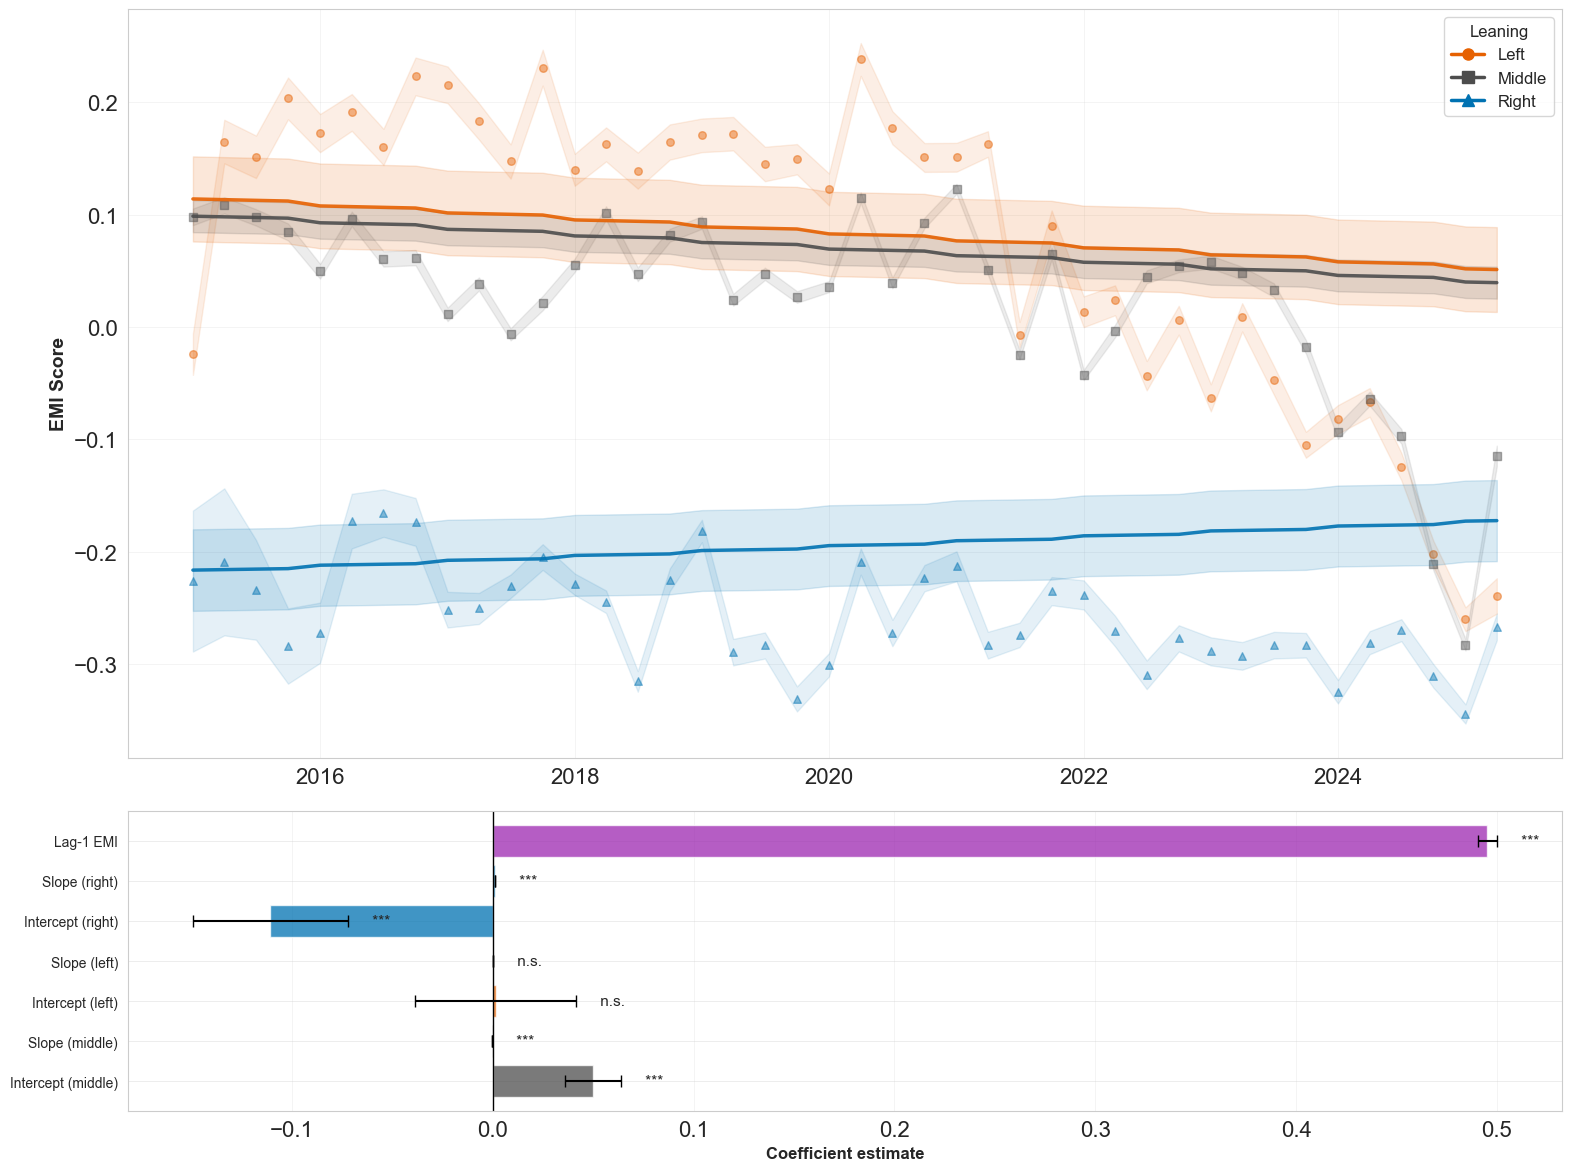

Saved to results\twitter\plots\model_diagnostics.png


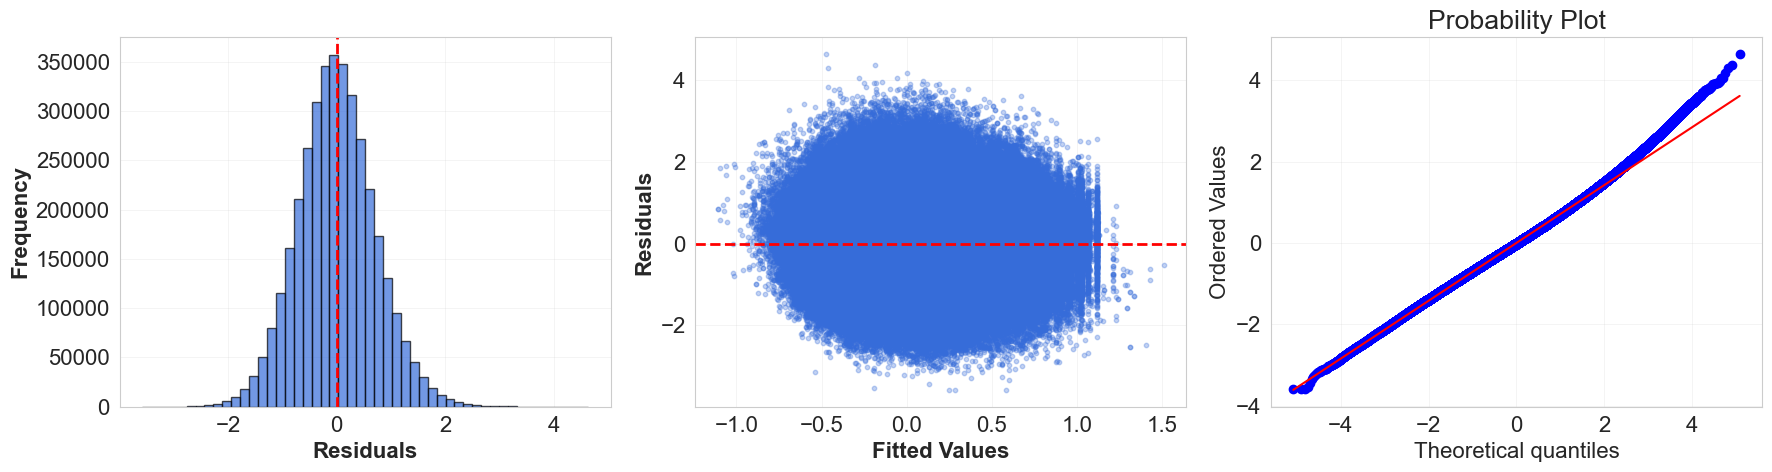

C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:898: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').min(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:899: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').max(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:908: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_group['quarter_date'] = df_group[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:908: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_group['quarter_date'] = df_group[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:908: UserWarning: Converting to PeriodArray/

Saved to results\twitter\plots\rq1_temporal_trends.png


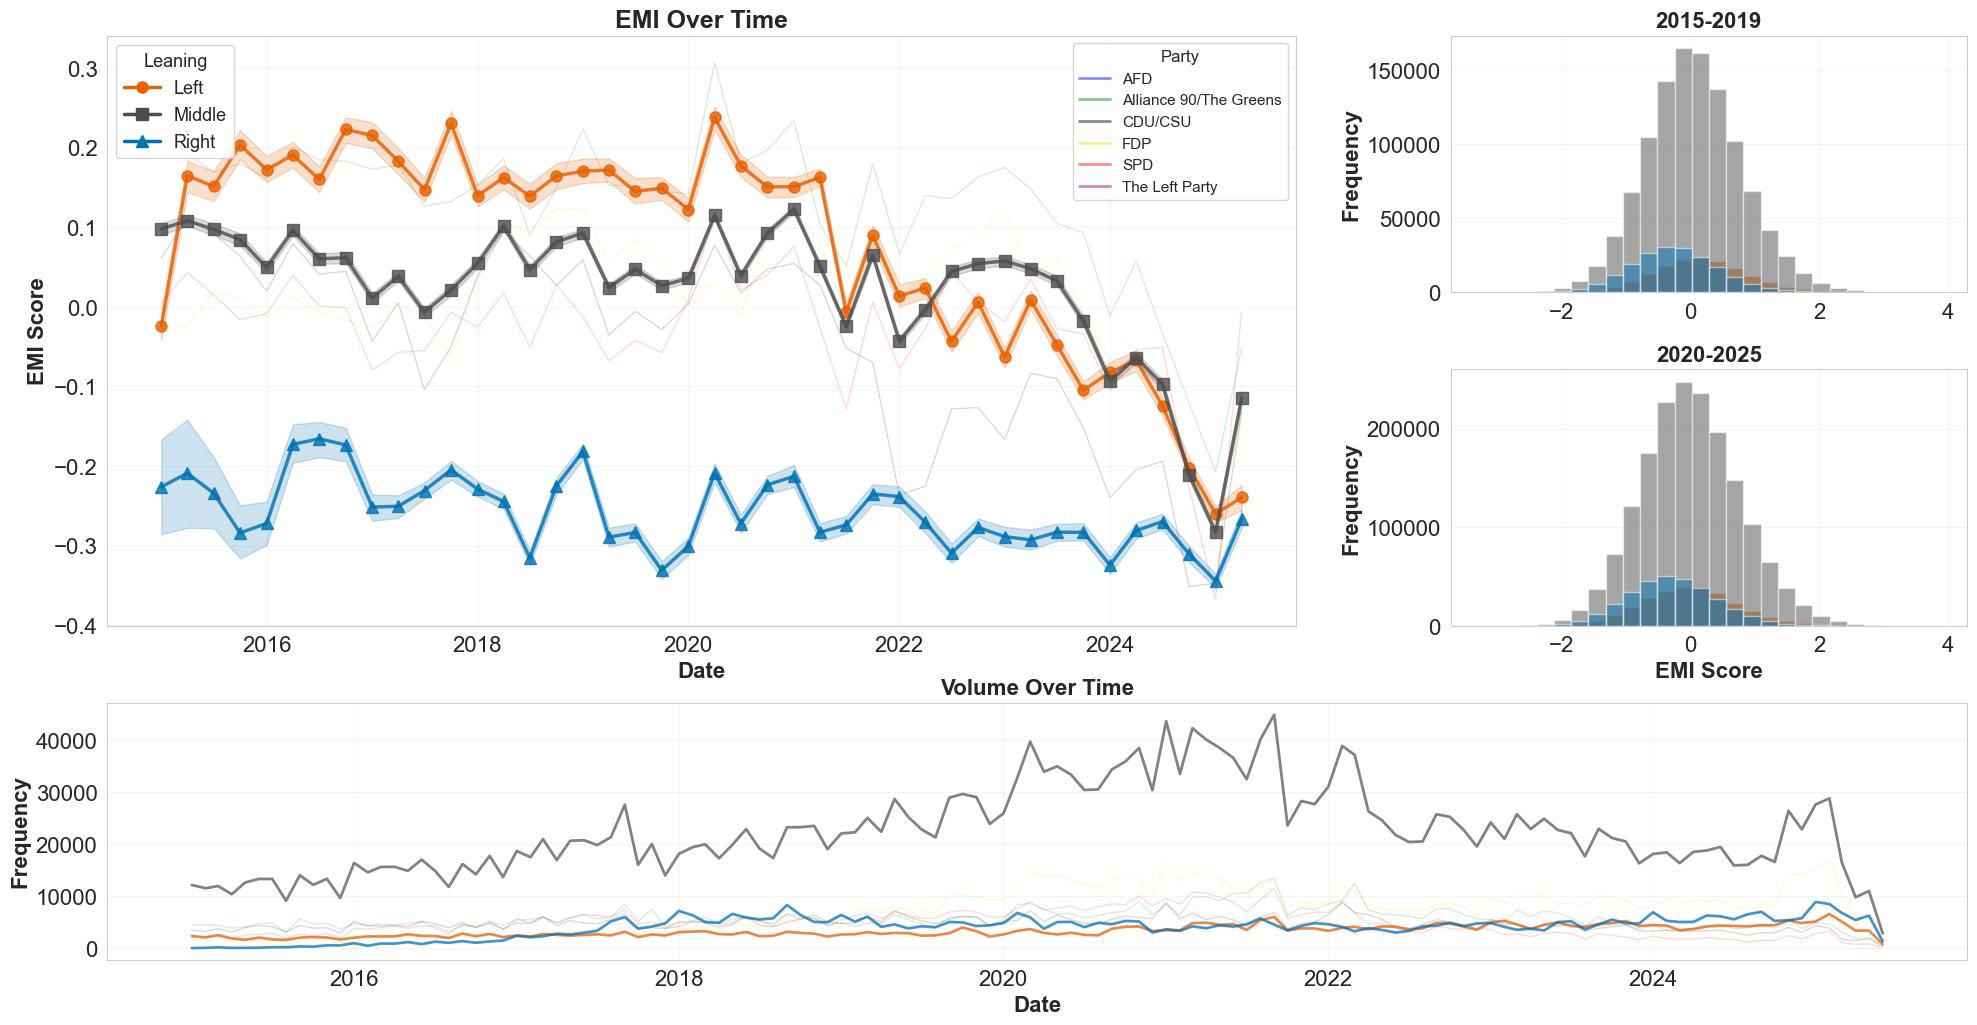

C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:1028: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_leaning['quarter_date'] = df_leaning[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:1028: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_leaning['quarter_date'] = df_leaning[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:1028: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_leaning['quarter_date'] = df_leaning[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:1028: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_leaning['quarter_date'] = df_leaning[date_col].dt.to_period('Q').dt.to_timestamp()


Saved to results\twitter\plots\emi_components.png


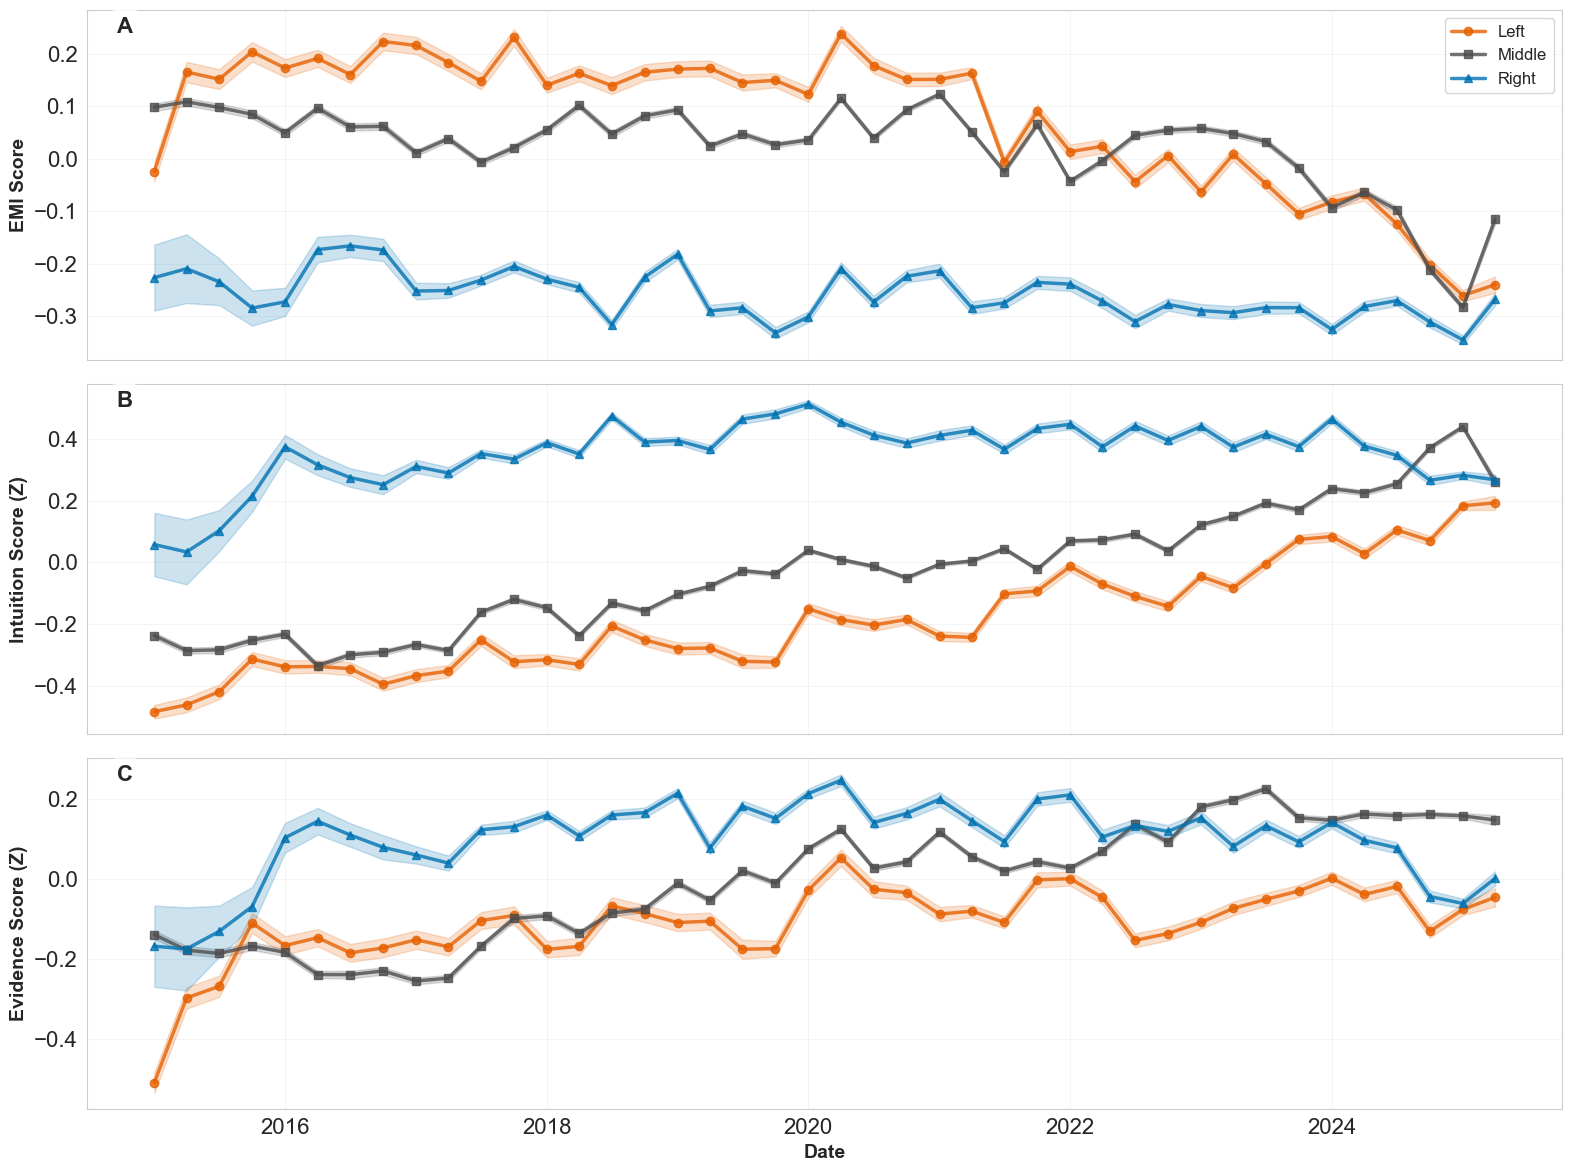


COMPLETED: Twitter
All results saved to: results\twitter



In [5]:
twitter_config = {
    'dataset_name': 'Twitter',
    'date_column': 'created_at',
    'group_column': 'party',
    'leaning_column': 'leaning',
    'id_column': 'author_id',
    'dropna_cols': ['party'],
    'metric_cols': {'engagement': 'like_count'},
    'metric_type': 'simple',
    'control_col_name': 'log_like_count',  # Match original analysis
    'split_year': 2020
}

twitter_results = run_complete_analysis(
    filepath='data/twitter_nhb.csv',
    config=twitter_config,
    output_dir='results'
)

## Parliament Analysis


ANALYZING: Parliament

Output directory: results\parliament
Loading data from data/parliament_nhb.csv...


C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:13: DtypeWarning: Columns (9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Converting date to datetime...
Creating temporal features...


C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['time_quarterly'] = df[date_column].dt.to_period('Q').astype(str).str.replace('Q', '').astype(int)


Loaded 56213 records
Date range: 2015-01-14 00:00:00+00:00 to 2025-06-06 00:00:00+00:00
Unique party: 7
Leaning distribution:
leaning
middle    42306
left       7191
right      6716
Name: count, dtype: int64

=== Correlation Analysis ===
Correlation between Evidence and Intuition: 0.1729

EMI Score Summary:
count    56213.000000
mean        -0.051693
std          1.295975
min         -4.176821
25%         -0.959184
50%         -0.069729
75%          0.836515
max          5.063669
Name: emi_w2vparliament, dtype: float64

=== Summary by party ===
                    party      mean       std  count leaning        se  \
0                     AFD -0.569423  1.262675   6716   right  0.015408   
1  Alliance 90/The Greens -0.083407  1.243944   6208  middle  0.015788   
2                     BSW -1.204966  1.396763    153    left  0.112922   
3                 CDU/CSU  0.078289  1.290598  16690  middle  0.009990   
4                     FDP -0.131811  1.216459   6146  middle  0.015517   
5    

C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:274: UserWarning: Converting to Period representation will drop timezone information.
  name: int(str(ts.to_period('Q')).replace('Q', ''))


Fitting breakpoint model...
                  Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    emi_w2vparliament
No. Observations:      53252      Method:                ML               
No. Groups:            1217       Scale:                 1.0594           
Min. group size:       1          Log-Likelihood:        -78656.5775      
Max. group size:       362        Converged:             Yes              
Mean group size:       43.8                                               
--------------------------------------------------------------------------
                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                       0.603    0.076   7.939 0.000  0.454  0.752
leaning[T.left]                -0.139    0.069  -2.007 0.045 -0.275 -0.003
leaning[T.right]               -0.404    0.067  -6.039 0.000 -0.535 -0.273
time_centered   

C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:358: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').min(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:359: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').max(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:376: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_l['quarter_date'] = df_l[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:401: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  first_q = int(str(df_l[date_col].dt.to_period('Q').min()).replace('Q', ''))
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:402: UserWarning: Converting to PeriodArray/Index represen

Saved to results\parliament\plots\breakpoint_model.png


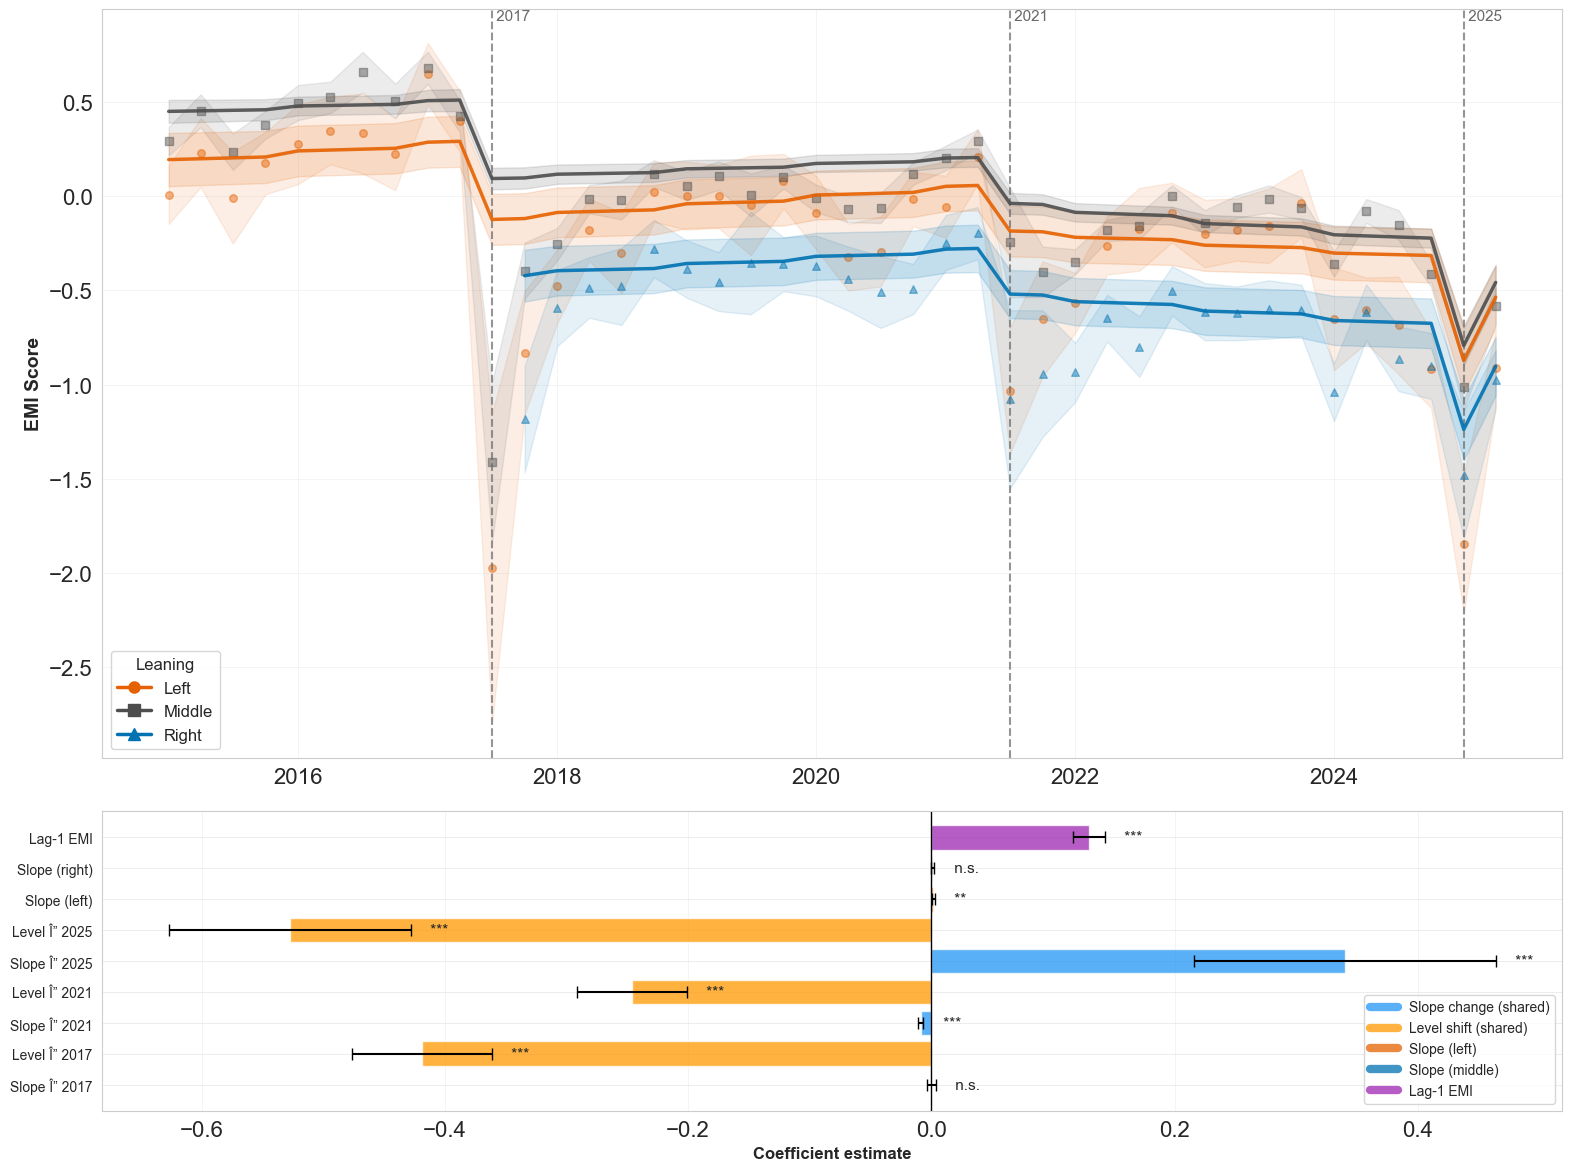


=== Full Breakpoint Model (leaning-specific slopes & level shifts) ===
DV: emi_w2vparliament | Random effects: politicianId
Breakpoints: ['elec2017', 'elec2021', 'elec2025']
Lag-1 added (prev-quarter group mean); lag_mean=-0.0571, N=53252
  Skipping elec2017:right interactions (group has no pre-breakpoint obs)
Formula: emi_w2vparliament ~ time_centered + leaning + time_centered:leaning + slope_elec2017 + level_elec2017 + slope_elec2017_left + level_elec2017_left + slope_elec2021 + level_elec2021 + slope_elec2021_left + level_elec2021_left + slope_elec2021_right + level_elec2021_right + slope_elec2025 + level_elec2025 + slope_elec2025_left + level_elec2025_left + slope_elec2025_right + level_elec2025_right + emi_lag1
Model N: 53252

Fitting null model...


C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:540: UserWarning: Converting to Period representation will drop timezone information.
  name: int(str(ts.to_period('Q')).replace('Q', ''))


Fitting full breakpoint model...


C:\Users\peers\working\phd\paper\nhb_emi\code\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


                  Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    emi_w2vparliament
No. Observations:      53252      Method:                ML               
No. Groups:            1217       Scale:                 1.0585           
Min. group size:       1          Log-Likelihood:        -78637.8571      
Max. group size:       362        Converged:             Yes              
Mean group size:       43.8                                               
--------------------------------------------------------------------------
                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                       0.569    0.085   6.662 0.000  0.402  0.737
leaning[T.left]                 0.011    0.186   0.061 0.951 -0.353  0.376
leaning[T.right]               -0.407    0.071  -5.713 0.000 -0.547 -0.268
time_centered                   0.002    0.0

C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:644: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').min(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:645: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').max(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:663: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_l['quarter_date'] = df_l[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:696: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  first_q = int(str(df_l[date_col].dt.to_period('Q').min()).replace('Q', ''))
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:697: UserWarning: Converting to PeriodArray/Index represen

Saved to results\parliament\plots\breakpoint_model_full.png


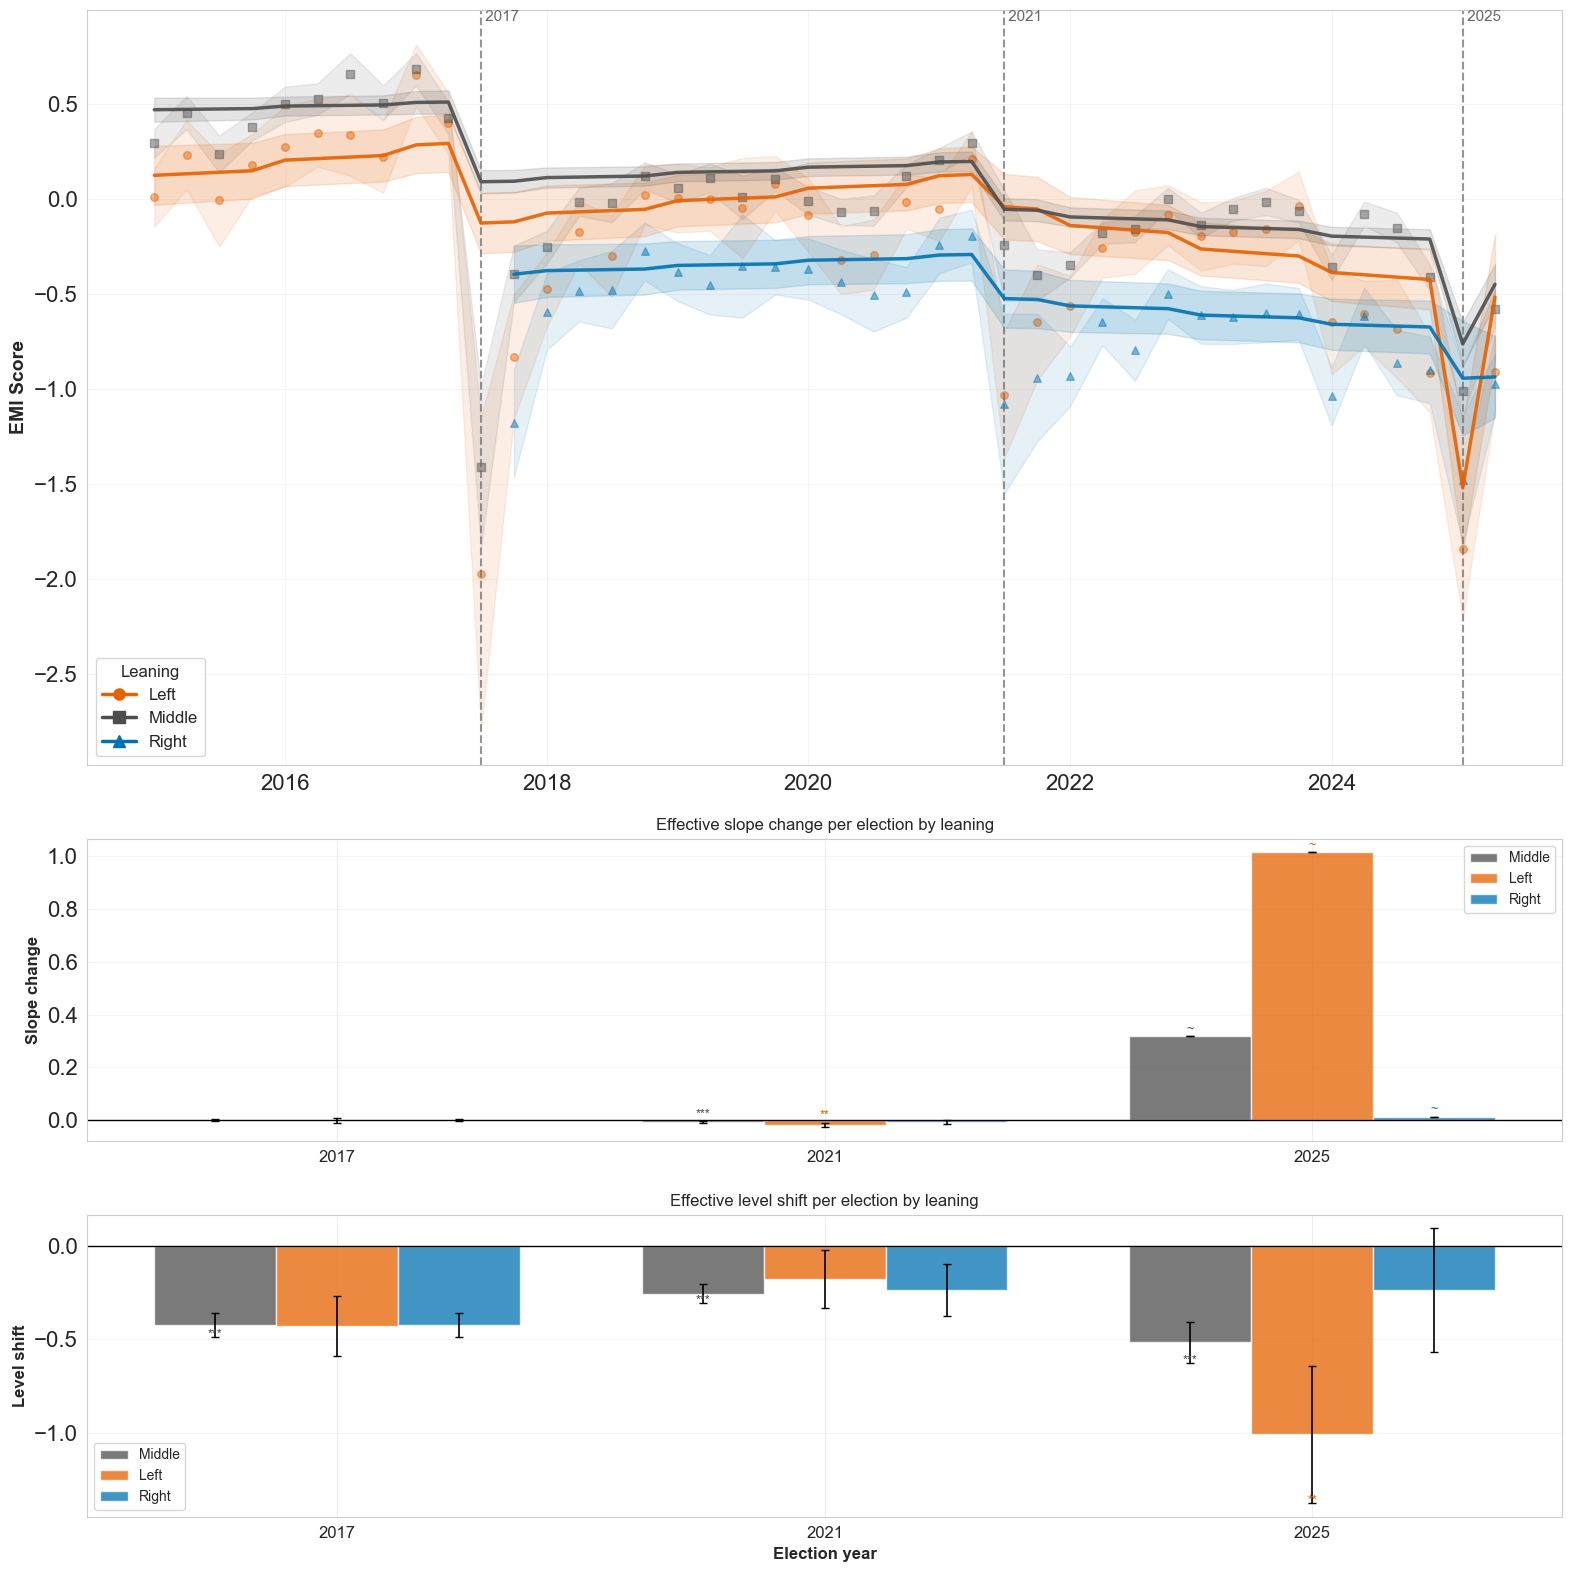

Saved both breakpoint models to results\parliament\models


C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:898: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').min(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:899: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').max(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:908: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_group['quarter_date'] = df_group[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:908: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_group['quarter_date'] = df_group[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:908: UserWarning: Converting to PeriodArray/

Saved to results\parliament\plots\rq1_temporal_trends.png


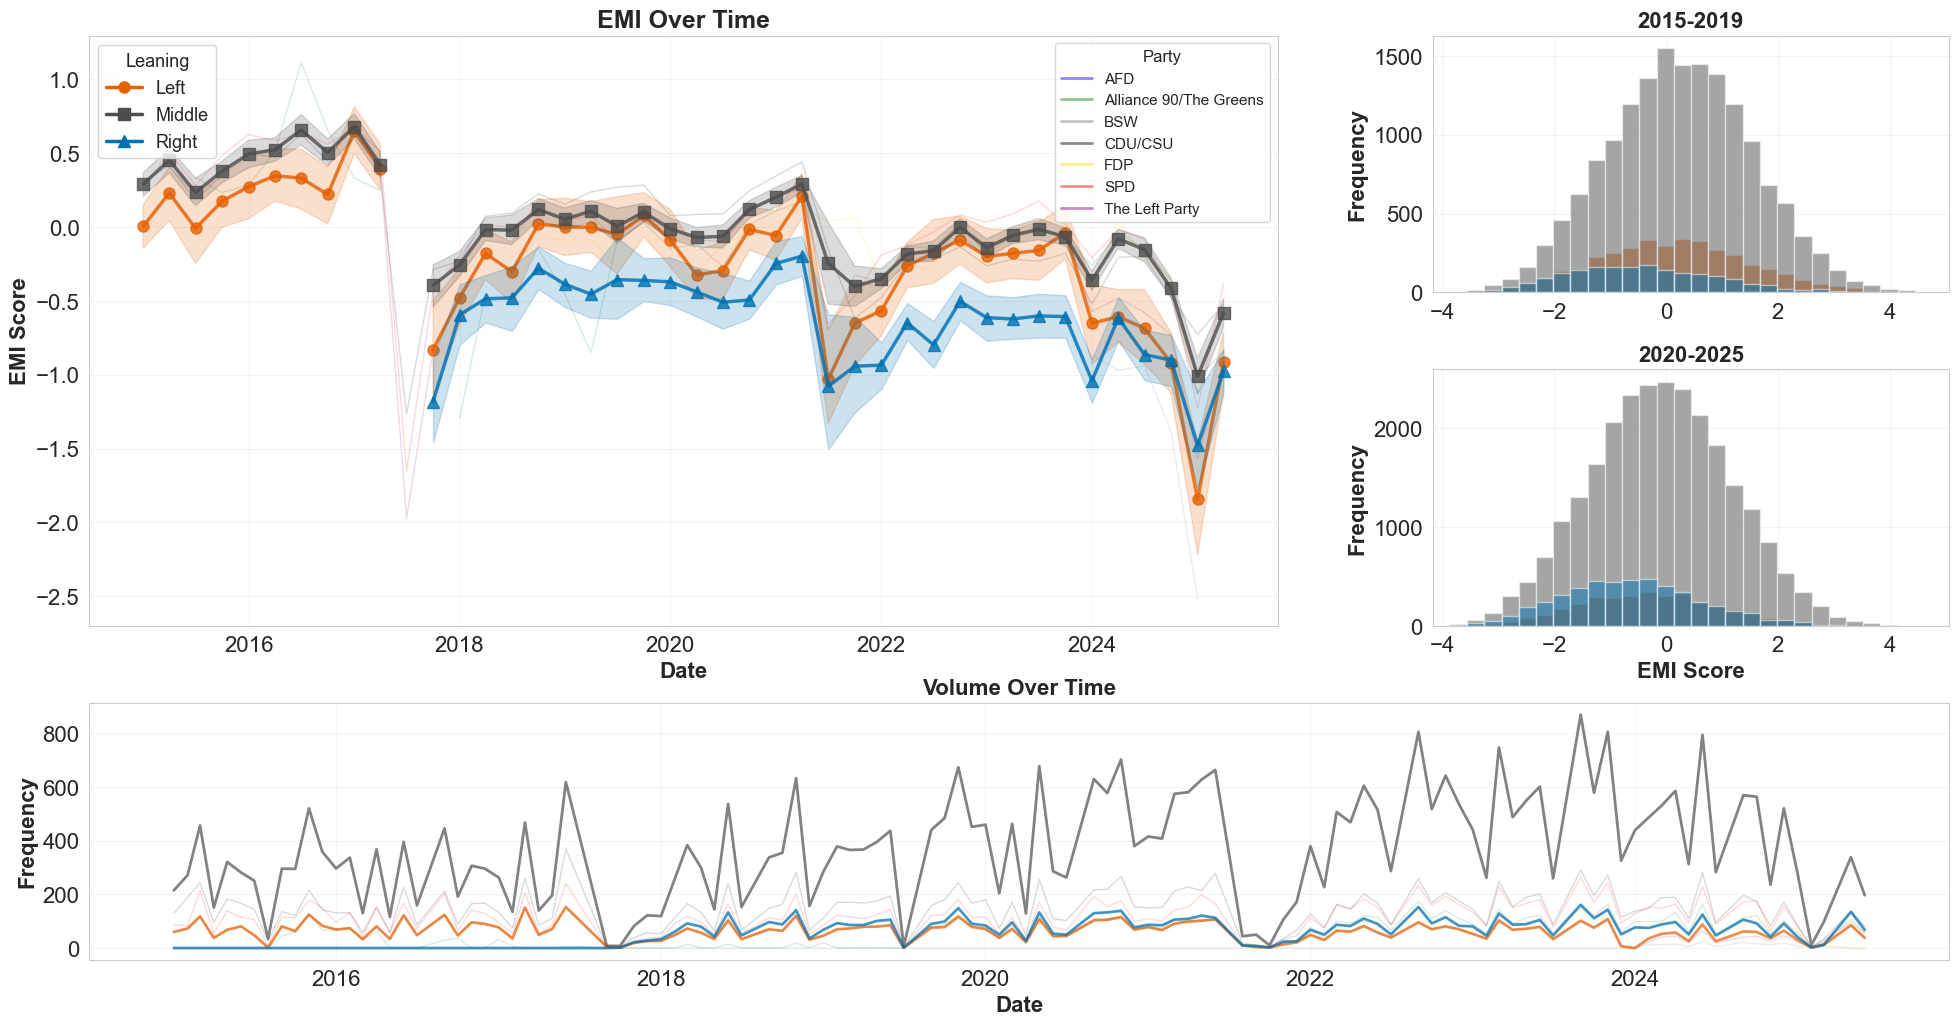

C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:1028: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_leaning['quarter_date'] = df_leaning[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:1028: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_leaning['quarter_date'] = df_leaning[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:1028: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_leaning['quarter_date'] = df_leaning[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:1028: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_leaning['quarter_date'] = df_leaning[date_col].dt.to_period('Q').dt.to_timestamp()


Saved to results\parliament\plots\emi_components.png


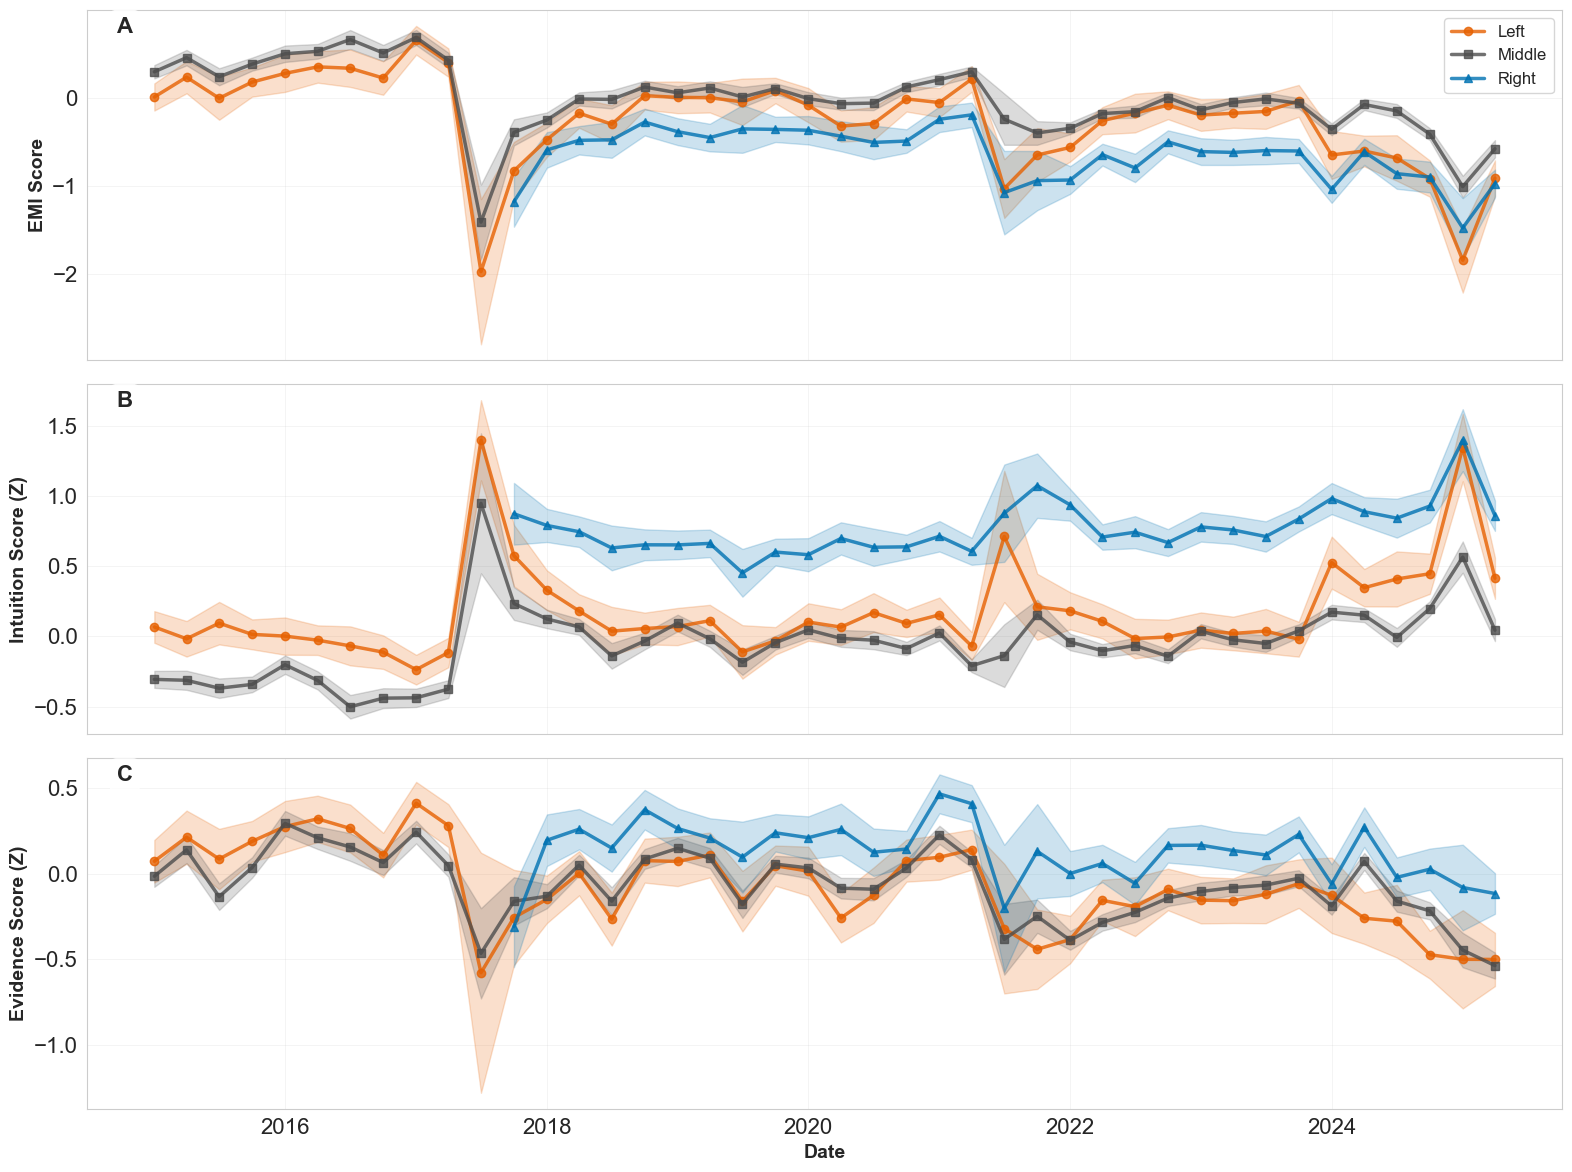


COMPLETED: Parliament
All results saved to: results\parliament



In [6]:
parliament_config = {
    'dataset_name': 'Parliament',
    'date_column': 'date',
    'group_column': 'party',
    'leaning_column': 'leaning',
    'id_column': 'politicianId',
    'dropna_cols': ['party', 'leaning'],
    'split_year': 2020,
    'model_type': 'breakpoint_both',
    'breakpoint_dates': {
        'elec2017': pd.Timestamp('2017-07-01', tz='UTC'),  # one year before 2017 election
        'elec2021': pd.Timestamp('2021-07-01', tz='UTC'),  # one year before 2021 election
        'elec2025': pd.Timestamp('2025-01-01', tz='UTC'),  # one year before 2025 election
    },
}

parliament_results = run_complete_analysis(
    filepath='data/parliament_nhb.csv',
    config=parliament_config,
    output_dir='results'
)

## Topic-Controlled Robustness Check

Final step. Re-fits the breakpoint MixedLM with topic fixed effects to address the agenda-setting confound. Operates on enriched datasets produced by `topic_modelling.ipynb`:

- `data/parliament_topics_nhb.csv` -- original parliament data + `topic` + `topic_prob`
- `data/twitter_topics_nhb.csv` -- original twitter data + `topic` + `topic_prob`

Documents with `topic == -1` (BERTopic outlier cluster) are dropped. The largest remaining topic is the reference category; the remaining K-1 topics enter as fixed-effect dummies.

Outputs land in `results/{dataset}/topic_robustness/` and do not overwrite the baseline results.


In [7]:
# ====================================================================
# Topic-Controlled Robustness Check -- function library
# ====================================================================
# One topic-controlled variant per existing baseline model.
# Mirrors run_complete_analysis dispatch logic.
# Outputs land in results/{dataset}/topic_robustness/ -- baseline untouched.

def _safe_diagnostics(full_result, df_model):
    """Run _model_diagnostics but tolerate singular random-effects covariance."""
    try:
        return _model_diagnostics(full_result, df_model)
    except (ValueError, np.linalg.LinAlgError) as e:
        print(f"  Diagnostics skipped (singular cov_re or related issue): {e}")
        return None


def _add_topic_fixed_effects(df_model, topic_col='topic', drop_outlier_topic=True):
    """Drop outliers, dummy-encode topics with the largest as reference."""
    df_model = df_model.copy()
    df_model[topic_col] = df_model[topic_col].astype(int)
    if drop_outlier_topic:
        n_out = int((df_model[topic_col] == -1).sum())
        df_model = df_model[df_model[topic_col] != -1].reset_index(drop=True)
        print(f"Dropped {n_out:,} outlier-topic docs (topic == -1)")

    counts = df_model[topic_col].value_counts()
    ref_topic = int(counts.idxmax())
    other_topics = [int(t) for t in counts.index if int(t) != ref_topic]
    print(f"Topic FE: {len(counts)} topics | reference = topic_{ref_topic} (n={int(counts.iloc[0]):,})")

    topic_terms = []
    for t in other_topics:
        col = f'topic_{t}'
        df_model[col] = (df_model[topic_col] == t).astype(float)
        topic_terms.append(col)
    return df_model, topic_terms, ref_topic, other_topics


def fit_mixed_model_topic_controlled(df, emi_col='emi_w2vparliament', control_col=None,
                                     interaction=True, topic_col='topic',
                                     drop_outlier_topic=True, diagnostics=True):
    """Mirrors fit_mixed_model with topic FE added (twitter baseline)."""
    id_col      = df.attrs['id_column']
    leaning_col = df.attrs['leaning_column']
    print(f"\n=== Topic-Controlled Mixed-Effects Model ===")
    print(f"DV: {emi_col} | Random effects: {id_col} | Topic column: {topic_col}")

    cols_needed = [emi_col, 'time_quarterly', leaning_col, id_col, topic_col]
    if control_col:
        cols_needed.append(control_col)
    df_model = df[cols_needed].copy().dropna()

    df_model, topic_terms, ref_topic, other_topics = _add_topic_fixed_effects(
        df_model, topic_col, drop_outlier_topic)

    df_model, lag_mean = _add_quarterly_lag(df_model, id_col, emi_col)

    time_mean = df_model['time_quarterly'].mean()
    df_model['time_centered'] = df_model['time_quarterly'] - time_mean
    print(f"Time variable centered at mean: {time_mean:.2f}")

    n_cats = df_model[leaning_col].nunique(dropna=True)
    if n_cats == 4:
        categories = ['middle', 'left', 'right', 'news/science']
        right_indices = df_model[df_model[leaning_col] == 'right'].sort_values('time_quarterly').index
        if len(right_indices) > 0:
            df_model = df_model.drop(right_indices[0])
            print(f"Removed first 'right' entry at index {right_indices[0]}")
    else:
        categories = ['middle', 'right', 'left']
    df_model[leaning_col] = pd.Categorical(df_model[leaning_col], categories=categories, ordered=False)
    df_model = df_model.reset_index(drop=True)

    formula = f"{emi_col} ~ time_centered * {leaning_col}" if interaction else f"{emi_col} ~ time_centered + {leaning_col}"
    if control_col:
        formula += f" + {control_col}"
    formula += " + emi_lag1"
    if topic_terms:
        formula += " + " + " + ".join(topic_terms)
    print(f"Formula has {len(topic_terms)} topic dummies | Model N: {len(df_model)}")

    print("\nFitting null model...")
    null_result = MixedLM.from_formula(f"{emi_col} ~ 1",
                                       groups=df_model[id_col], data=df_model).fit(reml=False)
    print("Fitting topic-controlled mixed model...")
    full_result = MixedLM.from_formula(formula,
                                       groups=df_model[id_col], data=df_model).fit(reml=False)
    print(full_result.summary())

    var_random   = null_result.cov_re.iloc[0, 0]
    var_residual = null_result.scale
    icc      = var_random / (var_random + var_residual)
    lrt_stat = -2 * (null_result.llf - full_result.llf)
    df_diff  = len(full_result.params) - len(null_result.params)
    lrt_p    = 1 - chi2.cdf(lrt_stat, df_diff)
    print(f"\nICC: {icc:.4f}")
    print(f"LRT: stat={lrt_stat:.4f}, df={df_diff}, p={lrt_p:.4e}")

    return {
        'null_result': null_result, 'full_result': full_result,
        'formula': formula, 'n_obs': len(df_model), 'time_center': time_mean,
        'lag_mean': lag_mean, 'df_model': df_model,
        'topic_col': topic_col, 'ref_topic': ref_topic, 'other_topics': other_topics,
        'icc': icc, 'lrt_statistic': lrt_stat, 'lrt_p': lrt_p,
        'null_aic': null_result.aic, 'null_bic': null_result.bic,
        'full_aic': full_result.aic, 'full_bic': full_result.bic,
        'diagnostics': _safe_diagnostics(full_result, df_model) if diagnostics else None,
    }


def fit_breakpoint_model_topic_controlled(df, emi_col='emi_w2vparliament',
                                          breakpoint_dates=None,
                                          include_level_shifts=True,
                                          topic_col='topic',
                                          drop_outlier_topic=True,
                                          diagnostics=True):
    """Mirrors fit_breakpoint_model (no leaning interactions on breakpoints) + topic FE."""
    if breakpoint_dates is None:
        breakpoint_dates = {
            'elec2017': pd.Timestamp('2017-09-24', tz='UTC'),
            'elec2021': pd.Timestamp('2021-09-26', tz='UTC'),
            'elec2025': pd.Timestamp('2025-02-23', tz='UTC'),
        }

    date_col    = df.attrs['date_column']
    id_col      = df.attrs['id_column']
    leaning_col = df.attrs['leaning_column']

    print(f"\n=== Topic-Controlled Breakpoint Model (no leaning interactions) ===")
    print(f"DV: {emi_col} | Random effects: {id_col} | Topic column: {topic_col}")
    print(f"Breakpoints: {list(breakpoint_dates.keys())}")

    cols_needed = [emi_col, date_col, 'time_quarterly', leaning_col, id_col, topic_col]
    df_model = df[cols_needed].copy().dropna()

    df_model, topic_terms, ref_topic, other_topics = _add_topic_fixed_effects(
        df_model, topic_col, drop_outlier_topic)

    df_model, lag_mean = _add_quarterly_lag(df_model, id_col, emi_col)

    time_mean = df_model['time_quarterly'].mean()
    df_model['time_centered'] = df_model['time_quarterly'] - time_mean

    bp_quarterly = {
        name: int(str(ts.to_period('Q')).replace('Q', ''))
        for name, ts in breakpoint_dates.items()
    }

    formula_terms = ['time_centered']
    for name, bp_val in bp_quarterly.items():
        bp_c = bp_val - time_mean
        df_model[f'slope_{name}'] = np.maximum(0.0, df_model['time_centered'] - bp_c)
        formula_terms.append(f'slope_{name}')
        if include_level_shifts:
            df_model[f'level_{name}'] = (df_model['time_quarterly'] >= bp_val).astype(float)
            formula_terms.append(f'level_{name}')

    df_model[leaning_col] = pd.Categorical(df_model[leaning_col],
                                           categories=['middle', 'left', 'right'],
                                           ordered=False)
    formula_terms.append(leaning_col)
    formula_terms.append(f'time_centered:{leaning_col}')
    formula_terms.append('emi_lag1')
    formula_terms.extend(topic_terms)

    df_model = df_model.reset_index(drop=True)

    formula = f"{emi_col} ~ {' + '.join(formula_terms)}"
    print(f"Formula: {len(formula_terms)} terms ({len(other_topics)} topic dummies) | Model N: {len(df_model)}")

    print("\nFitting null model...")
    null_result = MixedLM.from_formula(f"{emi_col} ~ 1",
                                       groups=df_model[id_col], data=df_model).fit(reml=False)
    print("Fitting topic-controlled breakpoint model...")
    full_result = MixedLM.from_formula(formula,
                                       groups=df_model[id_col], data=df_model).fit(reml=False)
    print(full_result.summary())

    var_random   = null_result.cov_re.iloc[0, 0]
    var_residual = null_result.scale
    icc      = var_random / (var_random + var_residual)
    lrt_stat = -2 * (null_result.llf - full_result.llf)
    df_diff  = len(full_result.params) - len(null_result.params)
    lrt_p    = 1 - chi2.cdf(lrt_stat, df_diff)
    print(f"\nICC: {icc:.4f}")
    print(f"LRT: stat={lrt_stat:.4f}, df={df_diff}, p={lrt_p:.4e}")

    return {
        'null_result': null_result, 'full_result': full_result,
        'formula': formula, 'n_obs': len(df_model), 'time_center': time_mean,
        'breakpoint_dates': breakpoint_dates, 'bp_quarterly': bp_quarterly,
        'include_level_shifts': include_level_shifts, 'df_model': df_model,
        'lag_mean': lag_mean,
        'topic_col': topic_col, 'ref_topic': ref_topic, 'other_topics': other_topics,
        'icc': icc, 'lrt_statistic': lrt_stat, 'lrt_p': lrt_p,
        'null_aic': null_result.aic, 'null_bic': null_result.bic,
        'full_aic': full_result.aic, 'full_bic': full_result.bic,
        'diagnostics': _safe_diagnostics(full_result, df_model) if diagnostics else None,
    }


def fit_breakpoint_model_topic_controlled_full(df, emi_col='emi_w2vparliament',
                                                breakpoint_dates=None,
                                                include_level_shifts=True,
                                                topic_col='topic',
                                                drop_outlier_topic=True,
                                                diagnostics=True):
    """Mirrors fit_breakpoint_model_full (leaning-specific slopes & shifts) + topic FE."""
    if breakpoint_dates is None:
        breakpoint_dates = {
            'elec2017': pd.Timestamp('2017-09-24', tz='UTC'),
            'elec2021': pd.Timestamp('2021-09-26', tz='UTC'),
            'elec2025': pd.Timestamp('2025-02-23', tz='UTC'),
        }

    date_col    = df.attrs['date_column']
    id_col      = df.attrs['id_column']
    leaning_col = df.attrs['leaning_column']

    print(f"\n=== Topic-Controlled Breakpoint Model (full, with leaning interactions) ===")
    print(f"DV: {emi_col} | Random effects: {id_col} | Topic column: {topic_col}")
    print(f"Breakpoints: {list(breakpoint_dates.keys())}")

    cols_needed = [emi_col, date_col, 'time_quarterly', leaning_col, id_col, topic_col]
    df_model = df[cols_needed].copy().dropna()

    df_model, topic_terms, ref_topic, other_topics = _add_topic_fixed_effects(
        df_model, topic_col, drop_outlier_topic)

    df_model, lag_mean = _add_quarterly_lag(df_model, id_col, emi_col)

    time_mean = df_model['time_quarterly'].mean()
    df_model['time_centered'] = df_model['time_quarterly'] - time_mean

    bp_quarterly = {
        name: int(str(ts.to_period('Q')).replace('Q', ''))
        for name, ts in breakpoint_dates.items()
    }

    formula_terms = ['time_centered', leaning_col, f'time_centered:{leaning_col}']
    non_ref_leanings = [l for l in df_model[leaning_col].dropna().unique() if l != 'middle']
    for name, bp_val in bp_quarterly.items():
        bp_c = bp_val - time_mean
        df_model[f'slope_{name}'] = np.maximum(0.0, df_model['time_centered'] - bp_c)
        formula_terms.append(f'slope_{name}')
        if include_level_shifts:
            df_model[f'level_{name}'] = (df_model['time_quarterly'] >= bp_val).astype(float)
            formula_terms.append(f'level_{name}')
        for lean in non_ref_leanings:
            lean_mask = (df_model[leaning_col] == lean)
            spans = (df_model.loc[lean_mask, 'time_quarterly'] < bp_val).any()
            if spans:
                col_s = f'slope_{name}_{lean}'
                df_model[col_s] = df_model[f'slope_{name}'] * lean_mask.astype(float)
                formula_terms.append(col_s)
                if include_level_shifts:
                    col_l = f'level_{name}_{lean}'
                    df_model[col_l] = df_model[f'level_{name}'] * lean_mask.astype(float)
                    formula_terms.append(col_l)
            else:
                print(f'  Skipping {name}:{lean} interactions (group has no pre-breakpoint obs)')

    formula_terms.append('emi_lag1')
    formula_terms.extend(topic_terms)

    df_model[leaning_col] = pd.Categorical(df_model[leaning_col],
                                           categories=['middle', 'left', 'right'],
                                           ordered=False)
    df_model = df_model.reset_index(drop=True)

    formula = f"{emi_col} ~ {' + '.join(formula_terms)}"
    print(f"Formula: {len(formula_terms)} terms ({len(other_topics)} topic dummies) | Model N: {len(df_model)}")

    print("\nFitting null model...")
    null_result = MixedLM.from_formula(f"{emi_col} ~ 1",
                                       groups=df_model[id_col], data=df_model).fit(reml=False)
    print("Fitting topic-controlled full breakpoint model...")
    for _method in [['lbfgs', 'bfgs', 'nm'], ['nm', 'powell']]:
        try:
            full_result = MixedLM.from_formula(formula,
                                               groups=df_model[id_col], data=df_model).fit(
                                               reml=False, method=_method)
            break
        except Exception as _e:
            print(f"  method {_method} failed: {_e}, trying next...")
    else:
        full_result = MixedLM.from_formula(formula, groups=df_model[id_col], data=df_model).fit(
            reml=False, method=['nm', 'powell'], maxiter=2000)
    print(full_result.summary())

    var_random   = null_result.cov_re.iloc[0, 0]
    var_residual = null_result.scale
    icc      = var_random / (var_random + var_residual)
    lrt_stat = -2 * (null_result.llf - full_result.llf)
    df_diff  = len(full_result.params) - len(null_result.params)
    lrt_p    = 1 - chi2.cdf(lrt_stat, df_diff)
    print(f"\nICC: {icc:.4f}")
    print(f"LRT: stat={lrt_stat:.4f}, df={df_diff}, p={lrt_p:.4e}")

    return {
        'null_result': null_result, 'full_result': full_result,
        'formula': formula, 'n_obs': len(df_model), 'time_center': time_mean,
        'breakpoint_dates': breakpoint_dates, 'bp_quarterly': bp_quarterly,
        'include_level_shifts': include_level_shifts, 'df_model': df_model,
        'lag_mean': lag_mean,
        'topic_col': topic_col, 'ref_topic': ref_topic, 'other_topics': other_topics,
        'icc': icc, 'lrt_statistic': lrt_stat, 'lrt_p': lrt_p,
        'null_aic': null_result.aic, 'null_bic': null_result.bic,
        'full_aic': full_result.aic, 'full_bic': full_result.bic,
        'diagnostics': _safe_diagnostics(full_result, df_model) if diagnostics else None,
    }


def run_topic_controlled_analysis(filepath, config, output_dir='results'):
    """Re-fit baseline regression with topic FE; dispatches on config['model_type'].

    Mirrors run_complete_analysis: linear (default) -> mixed model;
    'breakpoint' -> simple breakpoint; 'breakpoint_full' -> full breakpoint;
    'breakpoint_both' -> both. Outputs land in results/{dataset}/topic_robustness/.
    """
    import os

    dataset_name = config['dataset_name']
    dataset_dir  = os.path.join(output_dir, dataset_name.lower(), 'topic_robustness')
    os.makedirs(dataset_dir, exist_ok=True)

    print(f"\n{'='*80}\nTOPIC-CONTROLLED ANALYSIS: {dataset_name}\n{'='*80}\n")
    print(f"Output directory: {dataset_dir}")

    df = load_and_prepare_data(
        filepath=filepath,
        date_column=config['date_column'],
        group_column=config['group_column'],
        leaning_column=config['leaning_column'],
        id_column=config.get('id_column'),
        dropna_cols=list(set((config.get('dropna_cols') or []) + ['topic'])),
    )

    control_col = None
    if 'metric_cols' in config:
        control_col = config.get('control_col_name', 'log_influence')
        df[control_col] = calculate_influence_metric(
            df, config['metric_cols'], config.get('metric_type', 'simple'))

    model_type = config.get('model_type', 'linear')
    bp_dates   = config.get('breakpoint_dates')
    incl_lvl   = config.get('include_level_shifts', True)
    baseline_models_dir = os.path.join(output_dir, dataset_name.lower(), 'models')

    def _save(model, suffix=''):
        res = model['full_result']
        params_df = res.params.to_frame('coefficient')
        params_df['std_err'] = res.bse
        params_df['z_value'] = res.tvalues
        params_df['p_value'] = res.pvalues
        params_df.to_csv(os.path.join(dataset_dir, f'model_parameters{suffix}.csv'))
        with open(os.path.join(dataset_dir, f'model_summary{suffix}.txt'), 'w') as f:
            f.write(str(res.summary()))
        with open(os.path.join(dataset_dir, f'model_summary{suffix}_latex.txt'), 'w') as f:
            f.write(res.summary().as_latex())
        pd.DataFrame([{
            'icc': model['icc'],
            'lrt_statistic': model['lrt_statistic'], 'lrt_p': model['lrt_p'],
            'null_aic': model['null_aic'], 'null_bic': model['null_bic'],
            'full_aic': model['full_aic'], 'full_bic': model['full_bic'],
            'n_obs': model['n_obs'],
            'n_topics_in_model': len(model['other_topics']) + 1,
            'reference_topic':   model['ref_topic'],
        }]).to_csv(os.path.join(dataset_dir, f'model_fit_statistics{suffix}.csv'), index=False)
        return params_df

    def _comparison(params_df, baseline_path, suffix=''):
        if not (baseline_path and os.path.exists(baseline_path)):
            print(f"  (no baseline at {baseline_path}; comparison{suffix}.csv skipped)")
            return
        baseline = pd.read_csv(baseline_path, index_col=0)
        comp = (baseline[['coefficient', 'p_value']]
                .rename(columns={'coefficient': 'baseline_coef',
                                 'p_value':     'baseline_p'})
                .join(params_df[['coefficient', 'p_value']]
                      .rename(columns={'coefficient': 'topic_ctrl_coef',
                                       'p_value':     'topic_ctrl_p'}),
                      how='outer'))
        comp['delta']      = comp['topic_ctrl_coef'] - comp['baseline_coef']
        comp['pct_change'] = comp['delta'] / comp['baseline_coef'].replace(0, np.nan) * 100
        keep = ~comp.index.astype(str).str.startswith('topic_')
        comp.loc[keep].to_csv(os.path.join(dataset_dir, f'comparison{suffix}.csv'))
        print(f"  Saved comparison{suffix}.csv (baseline = {baseline_path})")

    def _try_plot(plot_fn, model, save_name, label):
        # Use closure-scope df so df.attrs (date_column etc.) is intact;
        # df_model loses .attrs through the [cols].copy().dropna() chain.
        try:
            plot_fn(df, model,
                    dataset_name=f"{dataset_name} ({label})",
                    save_path=os.path.join(dataset_dir, save_name))
        except Exception as e:
            print(f"  Plot generation skipped ({label}): {e}")

    results = {}

    if model_type == 'breakpoint':
        m = fit_breakpoint_model_topic_controlled(
            df, breakpoint_dates=bp_dates, include_level_shifts=incl_lvl, diagnostics=True)
        p = _save(m)
        _comparison(p, os.path.join(baseline_models_dir, 'model_parameters.csv'))
        _try_plot(plot_breakpoint_model, m,
                  'breakpoint_model_topic_controlled.png', 'topic-controlled')
        results['model'] = m

    elif model_type == 'breakpoint_full':
        m = fit_breakpoint_model_topic_controlled_full(
            df, breakpoint_dates=bp_dates, include_level_shifts=incl_lvl, diagnostics=True)
        p = _save(m)
        _comparison(p, os.path.join(baseline_models_dir, 'model_parameters.csv'))
        _try_plot(plot_breakpoint_model_full, m,
                  'breakpoint_model_topic_controlled.png', 'topic-controlled')
        results['model'] = m

    elif model_type == 'breakpoint_both':
        # Simple breakpoint
        m1 = fit_breakpoint_model_topic_controlled(
            df, breakpoint_dates=bp_dates, include_level_shifts=incl_lvl, diagnostics=True)
        p1 = _save(m1, suffix='')
        _comparison(p1, os.path.join(baseline_models_dir, 'model_parameters.csv'))
        _try_plot(plot_breakpoint_model, m1,
                  'breakpoint_model_topic_controlled.png', 'topic-controlled')
        # Full breakpoint
        m2 = fit_breakpoint_model_topic_controlled_full(
            df, breakpoint_dates=bp_dates, include_level_shifts=incl_lvl, diagnostics=True)
        p2 = _save(m2, suffix='_full')
        _comparison(p2, os.path.join(baseline_models_dir, 'model_parameters_full.csv'),
                    suffix='_full')
        _try_plot(plot_breakpoint_model_full, m2,
                  'breakpoint_model_topic_controlled_full.png', 'topic-controlled, full')
        results['model'] = m1
        results['model_full'] = m2

    else:  # linear / default -- basic mixed model (twitter baseline)
        m = fit_mixed_model_topic_controlled(
            df, control_col=control_col, interaction=True, diagnostics=True)
        p = _save(m)
        _comparison(p, os.path.join(baseline_models_dir, 'model_parameters.csv'))
        _try_plot(plot_mixed_model, m,
                  'mixed_model_topic_controlled.png', 'topic-controlled')
        results['model'] = m

    print(f"\nResults saved to {dataset_dir}\n")
    return results



TOPIC-CONTROLLED ANALYSIS: Parliament

Output directory: results\parliament\topic_robustness
Loading data from data/parliament_topics_nhb.csv...


C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:13: DtypeWarning: Columns (9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Converting date to datetime...
Creating temporal features...


C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['time_quarterly'] = df[date_column].dt.to_period('Q').astype(str).str.replace('Q', '').astype(int)
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\3776820789.py:145: UserWarning: Converting to Period representation will drop timezone information.
  name: int(str(ts.to_period('Q')).replace('Q', ''))


Loaded 56213 records
Date range: 2015-01-14 00:00:00+00:00 to 2025-06-06 00:00:00+00:00
Unique party: 7
Leaning distribution:
leaning
middle    42306
left       7191
right      6716
Name: count, dtype: int64

=== Topic-Controlled Breakpoint Model (no leaning interactions) ===
DV: emi_w2vparliament | Random effects: politicianId | Topic column: topic
Breakpoints: ['elec2017', 'elec2021', 'elec2025']
Dropped 24,130 outlier-topic docs (topic == -1)
Topic FE: 29 topics | reference = topic_0 (n=5,688)
Lag-1 added (prev-quarter group mean); lag_mean=0.0020, N=29915
Formula: 38 terms (28 topic dummies) | Model N: 29915

Fitting null model...
Fitting topic-controlled breakpoint model...
                  Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    emi_w2vparliament
No. Observations:      29915      Method:                ML               
No. Groups:            1179       Scale:                 0.9310           
Min. group size:       1       

C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:358: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').min(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:359: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').max(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:376: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_l['quarter_date'] = df_l[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:401: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  first_q = int(str(df_l[date_col].dt.to_period('Q').min()).replace('Q', ''))
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:402: UserWarning: Converting to PeriodArray/Index represen

Saved to results\parliament\topic_robustness\breakpoint_model_topic_controlled.png


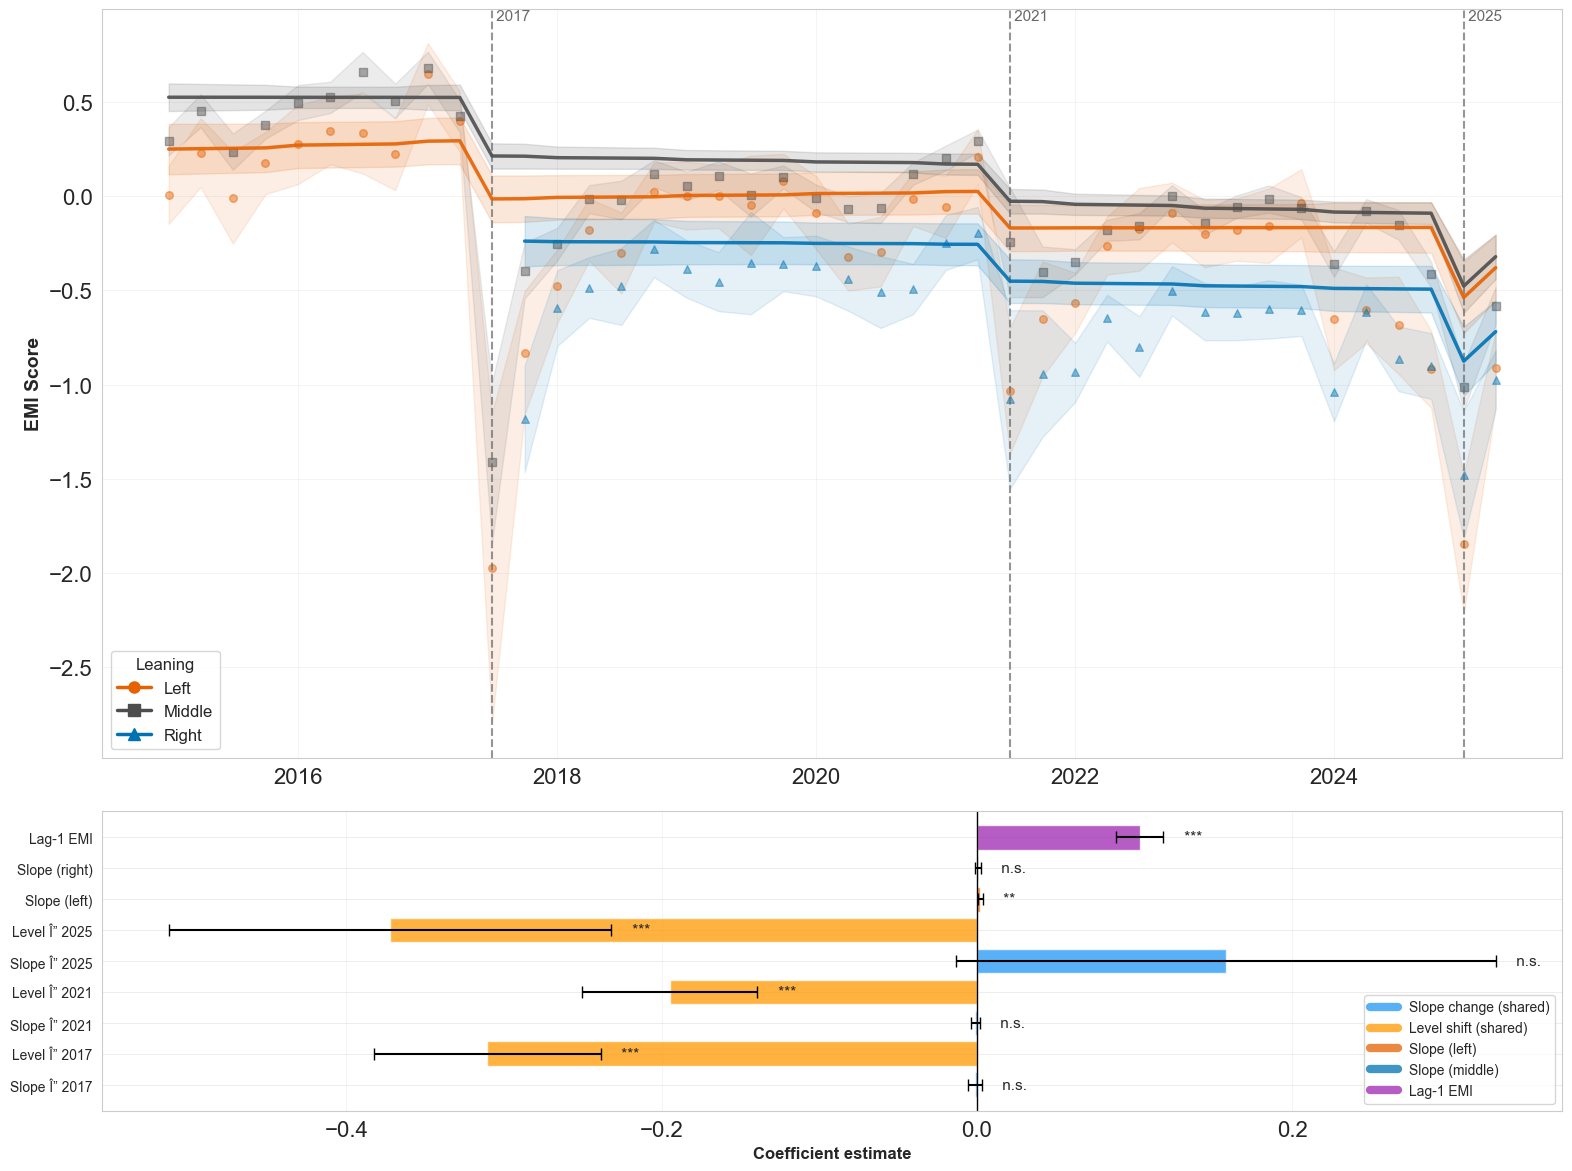


=== Topic-Controlled Breakpoint Model (full, with leaning interactions) ===
DV: emi_w2vparliament | Random effects: politicianId | Topic column: topic
Breakpoints: ['elec2017', 'elec2021', 'elec2025']
Dropped 24,130 outlier-topic docs (topic == -1)
Topic FE: 29 topics | reference = topic_0 (n=5,688)
Lag-1 added (prev-quarter group mean); lag_mean=0.0020, N=29915
  Skipping elec2017:right interactions (group has no pre-breakpoint obs)
Formula: 48 terms (28 topic dummies) | Model N: 29915

Fitting null model...


C:\Users\peers\AppData\Local\Temp\ipykernel_15592\3776820789.py:236: UserWarning: Converting to Period representation will drop timezone information.
  name: int(str(ts.to_period('Q')).replace('Q', ''))


Fitting topic-controlled full breakpoint model...


C:\Users\peers\working\phd\paper\nhb_emi\code\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\peers\working\phd\paper\nhb_emi\code\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\peers\working\phd\paper\nhb_emi\code\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\peers\working\phd\paper\nhb_emi\code\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\peers\working\phd\paper\nhb_emi\code\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarnin

                         Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         emi_w2vparliament
No. Observations:          29915           Method:                     ML               
No. Groups:                1179            Scale:                      0.8894           
Min. group size:           1               Log-Likelihood:             inf              
Max. group size:           230             Converged:                  Yes              
Mean group size:           25.4                                                         
----------------------------------------------------------------------------------------
                               Coef.    Std.Err.     z    P>|z|    [0.025       0.975]  
----------------------------------------------------------------------------------------
Intercept                       0.000 1523385.057   0.000 1.000 -2985779.846 2985779.846
leaning[T.left]                 0.651       0.5

C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:663: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_l['quarter_date'] = df_l[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:696: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  first_q = int(str(df_l[date_col].dt.to_period('Q').min()).replace('Q', ''))
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:697: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  last_q  = int(str(df_l[date_col].dt.to_period('Q').max()).replace('Q', ''))
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:663: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_l['quarter_date'] = df_l[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_1559

Saved to results\parliament\topic_robustness\breakpoint_model_topic_controlled_full.png


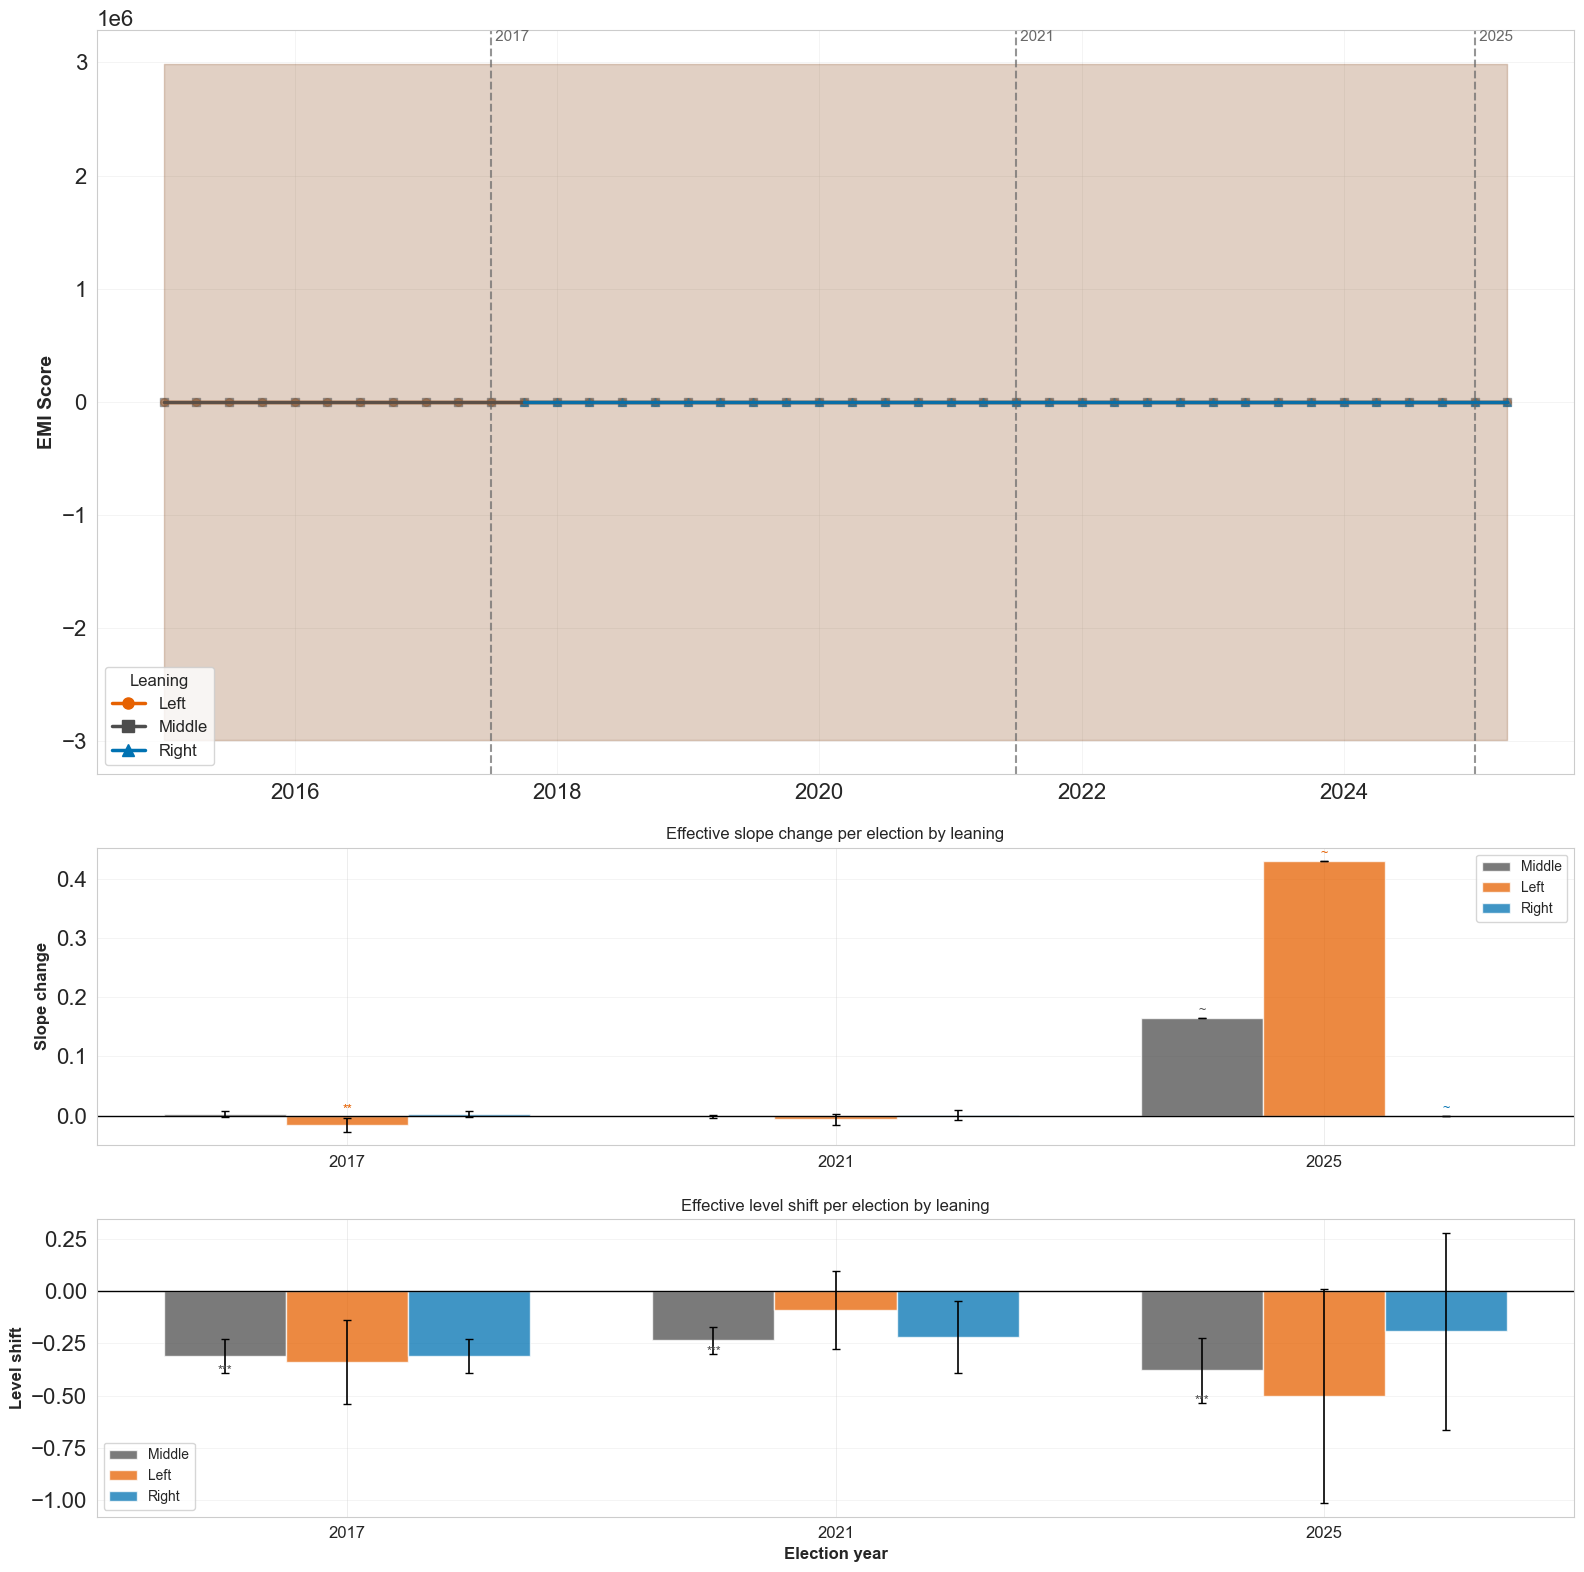


Results saved to results\parliament\topic_robustness



In [8]:
# Parliament -- topic-controlled (model_type='breakpoint_both' fits both simple + full)
parliament_topic_results = run_topic_controlled_analysis(
    filepath='data/parliament_topics_nhb.csv',
    config=parliament_config,
)



TOPIC-CONTROLLED ANALYSIS: Twitter

Output directory: results\twitter\topic_robustness
Loading data from data/twitter_topics_nhb.csv...


C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:13: DtypeWarning: Columns (3,4,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Converting created_at to datetime...
Creating temporal features...


C:\Users\peers\AppData\Local\Temp\ipykernel_15592\4269413306.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['time_quarterly'] = df[date_column].dt.to_period('Q').astype(str).str.replace('Q', '').astype(int)


Loaded 3776127 records
Date range: 2015-01-01 00:01:27+00:00 to 2025-06-08 01:02:08+00:00
Unique party: 6
Leaning distribution:
leaning
middle    2841948
right      508933
left       425246
Name: count, dtype: int64

=== Topic-Controlled Mixed-Effects Model ===
DV: emi_w2vparliament | Random effects: author_id | Topic column: topic
Dropped 1,999,606 outlier-topic docs (topic == -1)
Topic FE: 29 topics | reference = topic_0 (n=785,850)
Lag-1 added (prev-quarter group mean); lag_mean=0.0321, N=1743360
Time variable centered at mean: 20204.69
Formula has 28 topic dummies | Model N: 1743360

Fitting null model...
Fitting topic-controlled mixed model...
                   Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     emi_w2vparliament
No. Observations:     1743360     Method:                 ML               
No. Groups:           1037        Scale:                  0.4726           
Min. group size:      1           Log-Likelihood:         

C:\Users\peers\AppData\Local\Temp\ipykernel_15592\3426214364.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').min(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\3426214364.py:24: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df[date_col].dt.to_period('Q').max(),
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\3426214364.py:37: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_l['quarter_date'] = df_l[date_col].dt.to_period('Q').dt.to_timestamp()
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\3426214364.py:57: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  first_q = int(str(df_l[date_col].dt.to_period('Q').min()).replace('Q', ''))
C:\Users\peers\AppData\Local\Temp\ipykernel_15592\3426214364.py:58: UserWarning: Converting to PeriodArray/Index representatio

Saved to results\twitter\topic_robustness\mixed_model_topic_controlled.png


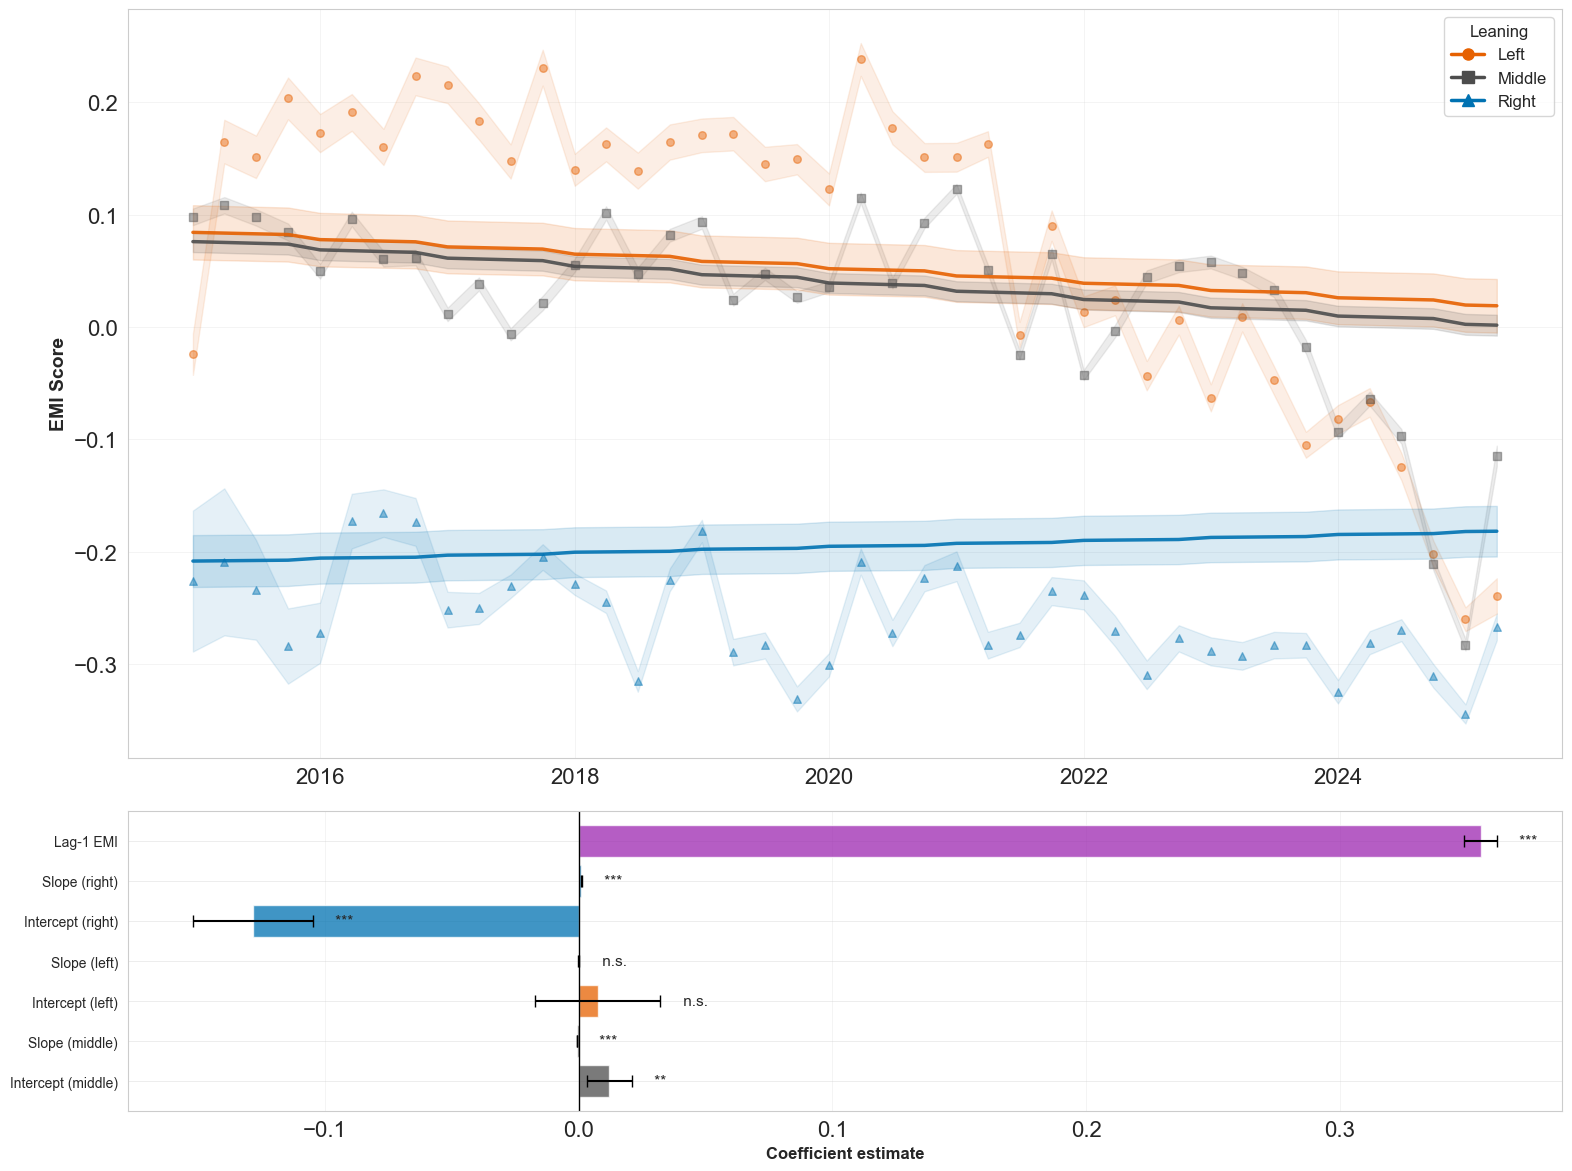


Results saved to results\twitter\topic_robustness



In [9]:
# Twitter -- topic-controlled (no model_type set => basic linear mixed model)
twitter_topic_results = run_topic_controlled_analysis(
    filepath='data/twitter_topics_nhb.csv',
    config=twitter_config,
)
